# personality-dungeon：時間序列分析（MVP）

這份 Notebook 只做分析：
- 讀取 `simulation/run_simulation.py` 輸出的 CSV
- 繪製策略比例與平均效用隨時間變化

設計原則：simulation 不依賴 matplotlib；只有 analysis / notebook 需要。

In [1]:
# 初始化（只保留這一格）：固定使用 venv kernel + 設定專案根目錄到 sys.path
from __future__ import annotations

import os
import sys
from pathlib import Path

# 直接指定 repo root，避免 cwd 變動造成 import 失敗
REPO_ROOT = Path('/home/user/personality-dungeon').resolve()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print('cwd:', Path.cwd())
print('python:', sys.executable)
print('sys.path[0]:', sys.path[0])

cwd: /home/user/personality-dungeon
python: /home/user/personality-dungeon/venv/bin/python
sys.path[0]: /home/user/personality-dungeon


## 1.（一次性）安裝 matplotlib（可選）

如果你只想看 ASCII 趨勢，可跳過這段，改用：
- `python -m analysis.plot_timeseries outputs/timeseries.csv`

若你要畫圖，請先在 venv 安裝：

```bash
pip install matplotlib
```

In [2]:
# 已在上一格初始化完成；此格保留為空（可刪除）

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt

from analysis.visualization import (
    load_timeseries_csv,
    plot_avg_reward,
    plot_avg_utility,
    plot_proportions,
)

csv_path = Path('outputs') / 'timeseries.csv'
csv_path

PosixPath('outputs/timeseries.csv')

In [4]:
ts = load_timeseries_csv(csv_path)
len(ts.rounds), list(ts.proportions.keys())

(20, ['aggressive', 'defensive', 'balanced'])

## 2. 策略比例（proportions）隨時間變化

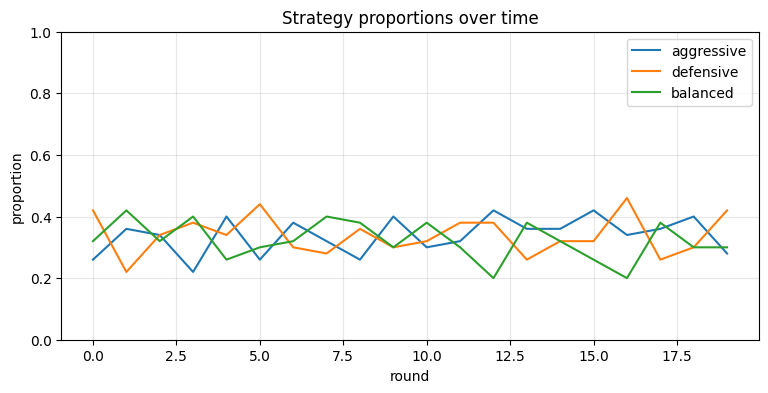

In [5]:
plt.figure(figsize=(9, 4))
plot_proportions(ts, title='Strategy proportions over time')
plt.show()

## 3. 平均效用與平均 reward 隨時間變化

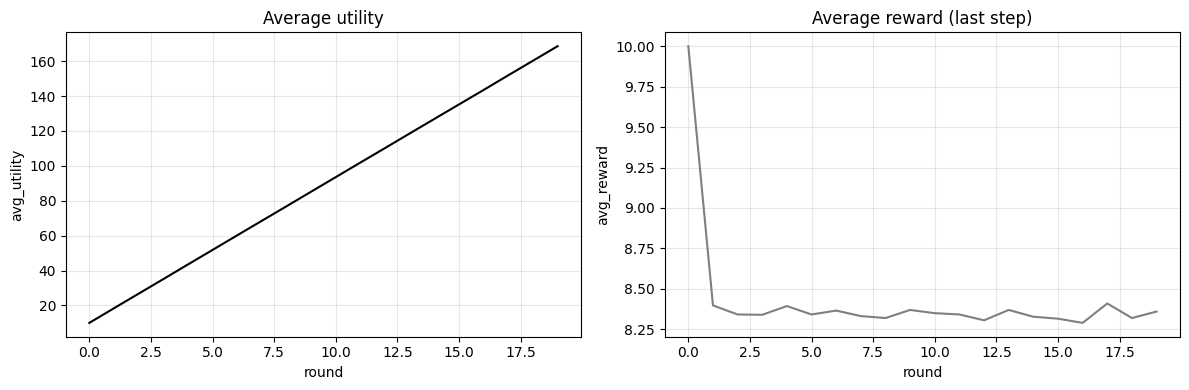

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

plt.sca(ax[0])
plot_avg_utility(ts, title='Average utility')

plt.sca(ax[1])
plot_avg_reward(ts, title='Average reward (last step)')

plt.tight_layout()
plt.show()

## 4. 下一步（參數掃描）

你可以先用不同參數輸出多份 CSV：

```bash
python -m simulation.run_simulation --gamma 0.05 --out outputs/g0.05.csv
python -m simulation.run_simulation --gamma 0.20 --out outputs/g0.20.csv
```

再在 Notebook 讀取多個 CSV 疊圖比較。

## 5. 參數掃描（parameter sweep）：gamma / selection_strength

目標：先理解最小模型的動態型態（收斂 / 震盪 / 壟斷 / 可能的臨界點），而不是加新模組。

> 這一節會反覆呼叫 `simulation.run_simulation` 輸出多份 CSV，再把時間序列疊圖比較。

In [31]:
import contextlib
import importlib
import io
import math
import sys
from pathlib import Path
from statistics import mean, pstdev

import matplotlib.pyplot as plt

from analysis.visualization import TimeSeries, load_timeseries_csv

import dungeon.dungeon_ai as dungeon_ai
import simulation.run_simulation as sim

# 確保你改完檔案後，notebook kernel 也拿到最新版（包含 --epsilon 與 DungeonAI(epsilon=...)）
importlib.reload(dungeon_ai)
importlib.reload(sim)


def _fmt_float_for_filename(x: float) -> str:
    # 0.05 -> 0p05，避免檔名中的 '.' 造成工具/平台差異
    s = f"{x:g}"
    return s.replace("-", "m").replace(".", "p")


def run_once_to_csv(
    *,
    gamma: float,
    selection_strength: float,
    rounds: int,
    players: int,
    out_csv: Path,
    epsilon: float = 0.0,
    quiet: bool = True,
) -> Path:
    """Run one simulation and write CSV by calling sim.main() with a temporary argv."""
    # 這裡 reload 一次，避免你來回修改 payoff/CLI 參數時 kernel 還是舊版
    importlib.reload(dungeon_ai)
    importlib.reload(sim)

    argv_backup = sys.argv[:]
    try:
        sys.argv = [
            "simulation.run_simulation",
            "--players",
            str(players),
            "--rounds",
            str(rounds),
            "--gamma",
            str(gamma),
            "--epsilon",
            str(epsilon),
            "--selection-strength",
            str(selection_strength),
            "--out",
            str(out_csv),
        ]
        if quiet:
            buf = io.StringIO()
            with contextlib.redirect_stdout(buf), contextlib.redirect_stderr(buf):
                sim.main()
        else:
            sim.main()
    finally:
        sys.argv = argv_backup
    return out_csv


def _finite(xs: list[float]) -> list[float]:
    return [float(x) for x in xs if isinstance(x, (int, float)) and math.isfinite(float(x))]


def tail_summary(series: list[float], *, window: int = 200) -> dict[str, float]:
    series = _finite(series)
    tail = series[-window:] if len(series) >= window else series
    if not tail:
        return {"mean": float("nan"), "std": float("nan"), "amp": float("nan")}
    return {
        "mean": float(mean(tail)),
        "std": float(pstdev(tail)) if len(tail) >= 2 else 0.0,
        "amp": float(max(tail) - min(tail)),
    }


def std_last(series: list[float], *, window: int = 200) -> float:
    return float(tail_summary(series, window=window)["std"])


def rotation_strength(ts: TimeSeries, *, window: int = 200) -> float:
    """Detect cyclic motion in 3-strategy simplex via signed area per step.

    Noise around the interior tends to cancel (near 0). A stable limit cycle tends
    to produce a consistent non-zero circulation magnitude.
    """
    # Expect these keys; if missing, return nan.
    for key in ("aggressive", "defensive", "balanced"):
        if key not in ts.proportions:
            return float("nan")

    pA = ts.proportions["aggressive"]
    pD = ts.proportions["defensive"]
    pB = ts.proportions["balanced"]

    # Tail window
    if len(ts.rounds) < 2:
        return float("nan")
    start = max(0, len(ts.rounds) - window)
    pA = pA[start:]
    pD = pD[start:]
    pB = pB[start:]

    # Embed simplex into 2D triangle vertices: A=(0,0), D=(1,0), B=(1/2, sqrt(3)/2)
    sqrt3 = math.sqrt(3.0)
    xs: list[float] = []
    ys: list[float] = []
    for a, d, b in zip(pA, pD, pB):
        x = float(d) + 0.5 * float(b)
        y = (sqrt3 / 2.0) * float(b)
        xs.append(x)
        ys.append(y)

    if len(xs) < 2:
        return float("nan")

    # Signed area proxy: sum cross(pos_t, pos_{t+1}) / steps
    area2 = 0.0
    for x0, y0, x1, y1 in zip(xs[:-1], ys[:-1], xs[1:], ys[1:]):
        area2 += (x0 * y1 - y0 * x1)
    return abs(area2) / max(1, (len(xs) - 1))


def print_dynamics_summary(ts_map: dict[str, TimeSeries], *, window: int = 200) -> None:
    strategies = list(next(iter(ts_map.values())).proportions.keys()) if ts_map else []
    print(f"window={window}")
    for label, ts in ts_map.items():
        print(f"\n[{label}] rounds={len(ts.rounds)}")
        for s in strategies:
            stats = tail_summary(ts.proportions[s], window=window)
            print(f"  p_{s:<10} mean={stats['mean']:.3f} std={stats['std']:.3f} amp={stats['amp']:.3f}")
        r = tail_summary(ts.avg_reward, window=window)
        print(f"  avg_reward   mean={r['mean']:.3f} std={r['std']:.3f} amp={r['amp']:.3f}")
        rot = rotation_strength(ts, window=window)
        print(f"  rotation    {rot:.6f}")

In [44]:
# Rotation metrics (centered): translation-invariant signed/abs circulation
# Rationale: cross(pos_t, pos_{t+1}) depends on the chosen origin; centering by tail centroid
# makes the sign/magnitude reflect actual circulation direction in the simplex.

from statistics import mean


def _simplex_xy(ts: TimeSeries, *, window: int) -> tuple[list[float], list[float]]:
    for key in ("aggressive", "defensive", "balanced"):
        if key not in ts.proportions:
            return ([], [])

    pA = ts.proportions["aggressive"]
    pD = ts.proportions["defensive"]
    pB = ts.proportions["balanced"]

    if len(ts.rounds) < 2:
        return ([], [])

    start = max(0, len(ts.rounds) - window)
    pA = pA[start:]
    pD = pD[start:]
    pB = pB[start:]

    sqrt3 = math.sqrt(3.0)
    xs: list[float] = []
    ys: list[float] = []
    for a, d, b in zip(pA, pD, pB):
        x = float(d) + 0.5 * float(b)
        y = (sqrt3 / 2.0) * float(b)
        xs.append(x)
        ys.append(y)
    return xs, ys


def signed_rotation(ts: TimeSeries, *, window: int = 200) -> float:
    """Signed circulation strength (centered) in the 3-strategy simplex."""
    xs, ys = _simplex_xy(ts, window=window)
    if len(xs) < 2:
        return float("nan")

    cx = float(mean(xs))
    cy = float(mean(ys))

    area2 = 0.0
    for x0, y0, x1, y1 in zip(xs[:-1], ys[:-1], xs[1:], ys[1:]):
        x0 -= cx
        y0 -= cy
        x1 -= cx
        y1 -= cy
        area2 += (x0 * y1 - y0 * x1)

    return area2 / max(1, (len(xs) - 1))


def rotation_strength(ts: TimeSeries, *, window: int = 200) -> float:
    """Abs circulation strength (centered) in the 3-strategy simplex."""
    s = signed_rotation(ts, window=window)
    return abs(float(s)) if math.isfinite(float(s)) else float("nan")


print("rotation metrics updated: centered signed_rotation/rotation_strength")

rotation metrics updated: centered signed_rotation/rotation_strength


### 5.1 gamma sweep（最重要）

固定 `selection_strength`，掃描不同 `gamma`：
- 是否收斂？（amp/std 變小）
- 是否 oscillation / 週期？（amp 仍大且有規律）
- 是否固定某一策略壟斷？（某策略 p → 1）

In [8]:
# gamma sweep
N_PLAYERS = 50
N_ROUNDS = 100
SELECTION_STRENGTH = 0.05
GAMMAS = [0.0, 0.05, 0.1, 0.2, 0.5]

out_dir = Path("outputs") / "sweeps" / "gamma"
out_dir.mkdir(parents=True, exist_ok=True)

csv_paths: dict[str, Path] = {}
for g in GAMMAS:
    out_csv = out_dir / f"gamma_{_fmt_float_for_filename(g)}.csv"
    csv_paths[f"γ={g:g}"] = run_once_to_csv(
        gamma=g,
        selection_strength=SELECTION_STRENGTH,
        rounds=N_ROUNDS,
        players=N_PLAYERS,
        out_csv=out_csv,
    )

ts_map = {label: load_timeseries_csv(path) for label, path in csv_paths.items()}
list(csv_paths.items())

Wrote CSV: outputs/sweeps/gamma/gamma_0.csv
players=50 rounds=100 gamma=0.0 selection_strength=0.05
Final weights: {'aggressive': 1.0, 'defensive': 1.0, 'balanced': 1.0}
Wrote CSV: outputs/sweeps/gamma/gamma_0p05.csv
players=50 rounds=100 gamma=0.05 selection_strength=0.05
Final weights: {'aggressive': 1.0041704759638685, 'defensive': 0.9991621548209048, 'balanced': 0.9966673692152267}
Wrote CSV: outputs/sweeps/gamma/gamma_0p1.csv
players=50 rounds=100 gamma=0.1 selection_strength=0.05
Final weights: {'aggressive': 0.9983152942641236, 'defensive': 0.993336175961718, 'balanced': 1.0083485297741586}
Wrote CSV: outputs/sweeps/gamma/gamma_0p2.csv
players=50 rounds=100 gamma=0.2 selection_strength=0.05
Final weights: {'aggressive': 0.9962619230678037, 'defensive': 0.9668179334855979, 'balanced': 1.0369201434465987}
Wrote CSV: outputs/sweeps/gamma/gamma_0p5.csv
players=50 rounds=100 gamma=0.5 selection_strength=0.05
Final weights: {'aggressive': 1.0420382868888727, 'defensive': 0.96674423316

[('γ=0', PosixPath('outputs/sweeps/gamma/gamma_0.csv')),
 ('γ=0.05', PosixPath('outputs/sweeps/gamma/gamma_0p05.csv')),
 ('γ=0.1', PosixPath('outputs/sweeps/gamma/gamma_0p1.csv')),
 ('γ=0.2', PosixPath('outputs/sweeps/gamma/gamma_0p2.csv')),
 ('γ=0.5', PosixPath('outputs/sweeps/gamma/gamma_0p5.csv'))]

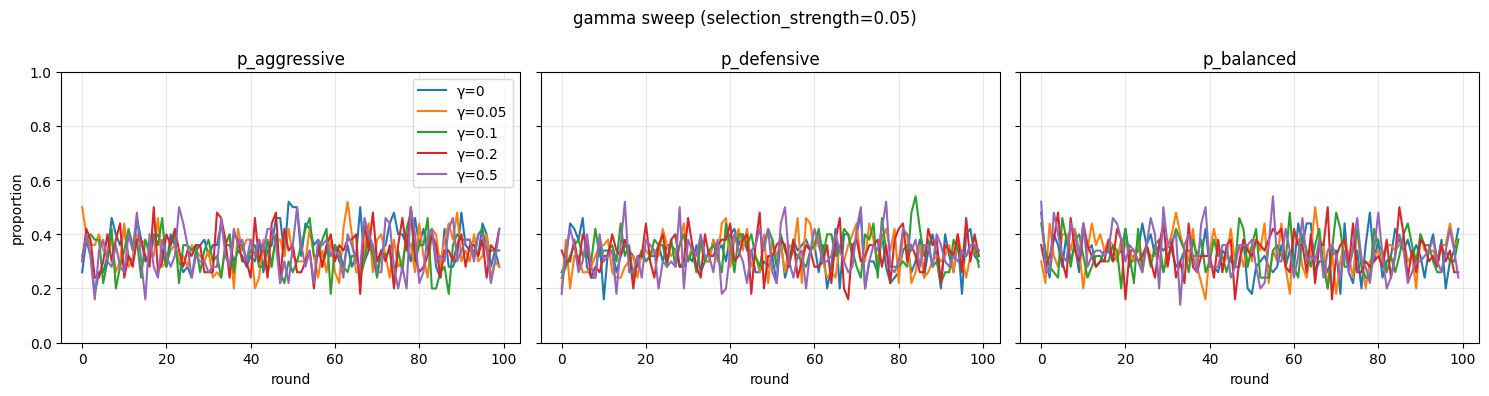

In [9]:
# 疊圖：每個策略一個 subplot（線條代表不同 gamma）
strategies = list(next(iter(ts_map.values())).proportions.keys())
fig, axs = plt.subplots(1, len(strategies), figsize=(5 * len(strategies), 4), sharey=True)
if len(strategies) == 1:
    axs = [axs]

for i, s in enumerate(strategies):
    ax = axs[i]
    for label, ts in ts_map.items():
        ax.plot(ts.rounds, ts.proportions[s], label=label)
    ax.set_title(f"p_{s}")
    ax.set_xlabel("round")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)

axs[0].set_ylabel("proportion")
axs[0].legend()
plt.suptitle(f"gamma sweep (selection_strength={SELECTION_STRENGTH:g})")
plt.tight_layout()
plt.show()

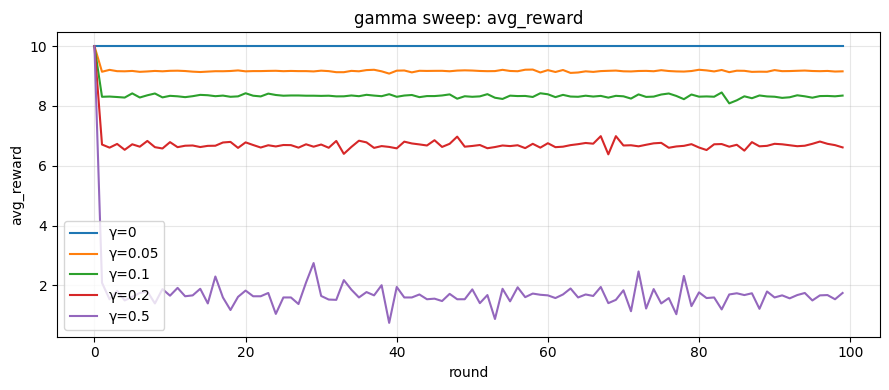

window=20

[γ=0] rounds=100
  p_aggressive mean=0.347 std=0.064 amp=0.240
  p_defensive  mean=0.319 std=0.067 amp=0.240
  p_balanced   mean=0.334 std=0.058 amp=0.220
  avg_reward   mean=10.000 std=0.000 amp=0.000
  avg_utility  mean=905.000 std=57.663 amp=190.000

[γ=0.05] rounds=100
  p_aggressive mean=0.348 std=0.068 amp=0.240
  p_defensive  mean=0.309 std=0.057 amp=0.180
  p_balanced   mean=0.343 std=0.048 amp=0.240
  avg_reward   mean=9.170 std=0.021 amp=0.080
  avg_utility  mean=830.457 std=52.860 amp=174.181

[γ=0.1] rounds=100
  p_aggressive mean=0.335 std=0.074 amp=0.280
  p_defensive  mean=0.334 std=0.076 amp=0.320
  p_balanced   mean=0.331 std=0.051 amp=0.180
  avg_reward   mean=8.305 std=0.069 amp=0.364
  avg_utility  mean=755.696 std=47.864 amp=157.790

[γ=0.2] rounds=100
  p_aggressive mean=0.333 std=0.051 amp=0.180
  p_defensive  mean=0.345 std=0.065 amp=0.240
  p_balanced   mean=0.322 std=0.062 amp=0.260
  avg_reward   mean=6.681 std=0.074 amp=0.304
  avg_utility  mean=6

In [14]:
# 疊圖：avg_reward（每回合）看動態型態 + 收斂指標（最後 window）
plt.figure(figsize=(9, 4))
for label, ts in ts_map.items():
    plt.plot(ts.rounds, ts.avg_reward, label=label)
plt.xlabel("round")
plt.ylabel("avg_reward")
plt.title("gamma sweep: avg_reward")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print_dynamics_summary(ts_map, window=20)

### 5.2 selection_strength sweep（動態穩定性）

固定 `gamma`，掃描 replicator 的 `selection_strength`：
- 很小（0.001）：更新慢、噪音相對大
- 中等（0.01）：常見穩定設定
- 很大（0.1）：可能過快、引發震盪或不穩定

In [11]:
# selection_strength sweep
N_PLAYERS = 50
N_ROUNDS = 100
GAMMA = 0.1
SELECTION_STRENGTHS = [0.001, 0.01, 0.1]

out_dir = Path("outputs") / "sweeps" / "selection_strength"
out_dir.mkdir(parents=True, exist_ok=True)

csv_paths_k: dict[str, Path] = {}
for k in SELECTION_STRENGTHS:
    out_csv = out_dir / f"k_{_fmt_float_for_filename(k)}.csv"
    csv_paths_k[f"k={k:g}"] = run_once_to_csv(
        gamma=GAMMA,
        selection_strength=k,
        rounds=N_ROUNDS,
        players=N_PLAYERS,
        out_csv=out_csv,
    )

ts_map_k = {label: load_timeseries_csv(path) for label, path in csv_paths_k.items()}
list(csv_paths_k.items())

Wrote CSV: outputs/sweeps/selection_strength/k_0p001.csv
players=50 rounds=100 gamma=0.1 selection_strength=0.001
Final weights: {'aggressive': 1.000266671106963, 'defensive': 0.9996666911162955, 'balanced': 1.0000666377767415}
Wrote CSV: outputs/sweeps/selection_strength/k_0p01.csv
players=50 rounds=100 gamma=0.1 selection_strength=0.01
Final weights: {'aggressive': 1.001667277129119, 'defensive': 0.9996659445745264, 'balanced': 0.9986667782963549}
Wrote CSV: outputs/sweeps/selection_strength/k_0p1.csv
players=50 rounds=100 gamma=0.1 selection_strength=0.1
Final weights: {'aggressive': 0.996661129706717, 'defensive': 0.996661129706717, 'balanced': 1.0066777405865657}


[('k=0.001', PosixPath('outputs/sweeps/selection_strength/k_0p001.csv')),
 ('k=0.01', PosixPath('outputs/sweeps/selection_strength/k_0p01.csv')),
 ('k=0.1', PosixPath('outputs/sweeps/selection_strength/k_0p1.csv'))]

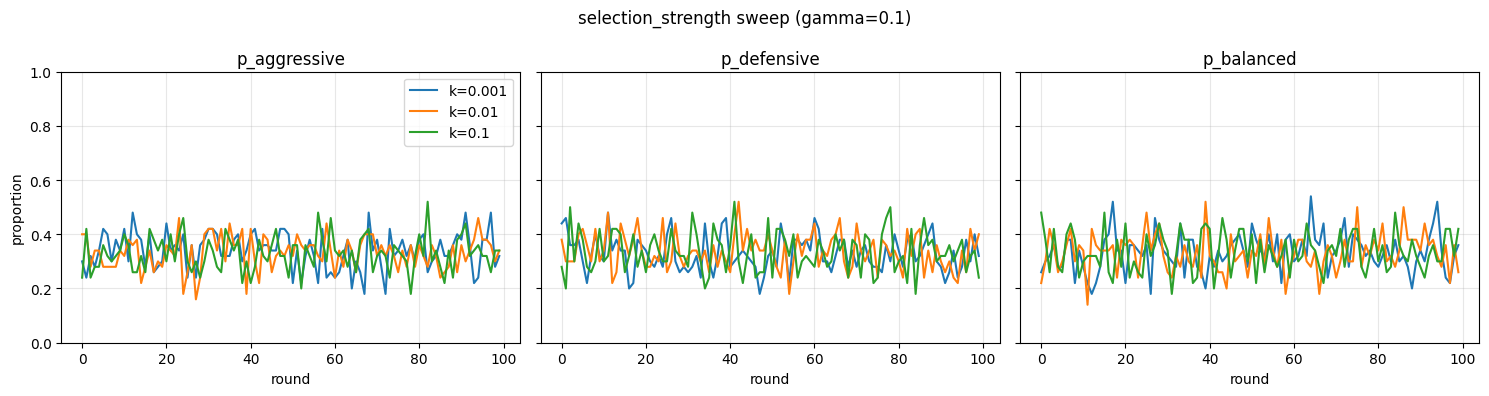

window=20

[k=0.001] rounds=100
  p_aggressive mean=0.348 std=0.068 amp=0.260
  p_defensive  mean=0.327 std=0.058 amp=0.220
  p_balanced   mean=0.325 std=0.071 amp=0.320
  avg_utility  mean=755.120 std=47.891 amp=157.928

[k=0.01] rounds=100
  p_aggressive mean=0.332 std=0.052 amp=0.220
  p_defensive  mean=0.319 std=0.066 amp=0.200
  p_balanced   mean=0.349 std=0.064 amp=0.280
  avg_utility  mean=756.114 std=47.988 amp=158.212

[k=0.1] rounds=100
  p_aggressive mean=0.339 std=0.067 amp=0.300
  p_defensive  mean=0.324 std=0.064 amp=0.280
  p_balanced   mean=0.337 std=0.060 amp=0.240
  avg_utility  mean=756.122 std=48.061 amp=158.428


In [12]:
# 疊圖：每個策略一個 subplot（線條代表不同 selection_strength） + 收斂指標（最後 window）
strategies = list(next(iter(ts_map_k.values())).proportions.keys())
fig, axs = plt.subplots(1, len(strategies), figsize=(5 * len(strategies), 4), sharey=True)
if len(strategies) == 1:
    axs = [axs]

for i, s in enumerate(strategies):
    ax = axs[i]
    for label, ts in ts_map_k.items():
        ax.plot(ts.rounds, ts.proportions[s], label=label)
    ax.set_title(f"p_{s}")
    ax.set_xlabel("round")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)

axs[0].set_ylabel("proportion")
axs[0].legend()
plt.suptitle(f"selection_strength sweep (gamma={GAMMA:g})")
plt.tight_layout()
plt.show()

print_dynamics_summary(ts_map_k, window=20)

### 5.3 噪音 vs 結構性動態：放大 N_PLAYERS

> 注意：目前模型的 popularity penalty 用的是「計數」（count），不是比例（proportion）。
因此當你改 N 而 gamma 不變時，有效強度其實變成 $\gamma \times N$，動態會被你「同時改參數」。

> 公平的噪音檢驗：讓 gamma 隨 $1/N$ 縮放（使 $\gamma N$ 近似常數），再看 `std_last_200` 是否隨 $1/\sqrt{N}$ 下降。

In [18]:
# N_PLAYERS sweep（噪音檢驗時，建議讓 gamma 隨 1/N 縮放以保持可比性）
GAMMA_BASE = 0.1
K_NOISE_TEST = 0.05
N_ROUNDS_NOISE_TEST = 400
N_PLAYERS_LIST = [50, 200, 500, 1000]

SCALE_GAMMA_WITH_N = True
N_REF = 50  # 以 N_REF 作為基準，讓 gamma * N 近似常數

out_dir = Path("outputs") / "sweeps" / "n_players"
out_dir.mkdir(parents=True, exist_ok=True)

ts_map_n: dict[str, TimeSeries] = {}
meta_n: dict[str, dict[str, float]] = {}
for n in N_PLAYERS_LIST:
    gamma_n = (GAMMA_BASE * (N_REF / n)) if SCALE_GAMMA_WITH_N else GAMMA_BASE
    out_csv = out_dir / (
        f"n_{n}_g_{_fmt_float_for_filename(gamma_n)}"
        f"_k_{_fmt_float_for_filename(K_NOISE_TEST)}"
        f"_scaled_{int(SCALE_GAMMA_WITH_N)}.csv"
    )
    run_once_to_csv(
        gamma=gamma_n,
        selection_strength=K_NOISE_TEST,
        rounds=N_ROUNDS_NOISE_TEST,
        players=n,
        out_csv=out_csv,
        quiet=True,
    )
    label = f"N={n}"
    ts_map_n[label] = load_timeseries_csv(out_csv)
    meta_n[label] = {"N": float(n), "gamma": float(gamma_n), "gammaN": float(gamma_n * n)}

print("loaded:", list(ts_map_n.keys()))
print("mode:", "gamma~1/N" if SCALE_GAMMA_WITH_N else "gamma fixed")
print("gammaN (should be ~constant if scaled):", {k: round(v["gammaN"], 3) for k, v in meta_n.items()})

loaded: ['N=50', 'N=200', 'N=500', 'N=1000']
mode: gamma~1/N
gammaN (should be ~constant if scaled): {'N=50': 5.0, 'N=200': 5.0, 'N=500': 5.0, 'N=1000': 5.0}


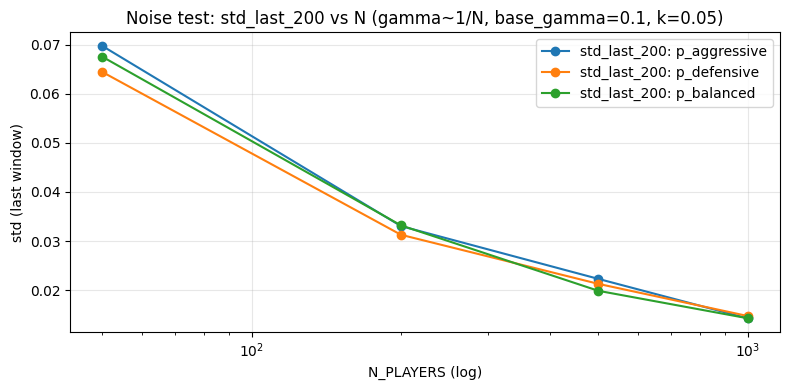


[N=50] gamma=0.1 gamma*N=5
  p_aggressive std=0.0697 amp=0.3800
  p_defensive  std=0.0644 amp=0.3400
  p_balanced   std=0.0675 amp=0.3400

[N=200] gamma=0.025 gamma*N=5
  p_aggressive std=0.0330 amp=0.2050
  p_defensive  std=0.0313 amp=0.2150
  p_balanced   std=0.0332 amp=0.1950

[N=500] gamma=0.01 gamma*N=5
  p_aggressive std=0.0223 amp=0.1280
  p_defensive  std=0.0213 amp=0.1180
  p_balanced   std=0.0199 amp=0.1040

[N=1000] gamma=0.005 gamma*N=5
  p_aggressive std=0.0143 amp=0.0830
  p_defensive  std=0.0147 amp=0.0700
  p_balanced   std=0.0143 amp=0.0770


In [19]:
# 指標：std_last_200 vs N（noise 主導通常會隨 N 增大而下降；log x 軸便於看縮放）
WINDOW = 200
strategies = list(next(iter(ts_map_n.values())).proportions.keys())
metric: dict[str, list[tuple[int, float]]] = {s: [] for s in strategies}

for label, ts in ts_map_n.items():
    n = int(label.split("=")[1])
    for s in strategies:
        metric[s].append((n, std_last(ts.proportions[s], window=WINDOW)))

plt.figure(figsize=(8, 4))
for s in strategies:
    xs = [n for (n, _) in sorted(metric[s])]
    ys = [v for (_, v) in sorted(metric[s])]
    plt.plot(xs, ys, marker="o", label=f"std_last_{WINDOW}: p_{s}")
plt.xscale("log")
plt.xlabel("N_PLAYERS (log)")
plt.ylabel("std (last window)")
mode = "gamma~1/N" if SCALE_GAMMA_WITH_N else "gamma fixed"
plt.title(f"Noise test: std_last_{WINDOW} vs N ({mode}, base_gamma={GAMMA_BASE:g}, k={K_NOISE_TEST:g})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 同時列印 tail std/amp，方便肉眼判讀是否存在 deterministic oscillation
for label, ts in ts_map_n.items():
    n = int(label.split("=")[1])
    g = meta_n[label]["gamma"]
    print(f"\n[{label}] gamma={g:g} gamma*N={g*n:g}")
    for s in strategies:
        stats = tail_summary(ts.proportions[s], window=WINDOW)
        print(f"  p_{s:<10} std={stats['std']:.4f} amp={stats['amp']:.4f}")

### 5.4 慢時間尺度：拉長 N_ROUNDS

> 目標：排除「需要很久才顯現」的慢收斂/慢週期。

建議：先固定較大的 N（例如 500），把 rounds 拉到 1000。

In [ ]:
# long-run test（這格可能較久）
LONG_N_PLAYERS = 500
LONG_N_ROUNDS = 1000
LONG_SELECTION_STRENGTH = 0.05
LONG_GAMMAS = [0.0, 0.2, 0.5]  # 可自行加密/改點

out_dir = Path("outputs") / "sweeps" / "long_run"
out_dir.mkdir(parents=True, exist_ok=True)

ts_map_long: dict[str, TimeSeries] = {}
for g in LONG_GAMMAS:
    out_csv = out_dir / f"long_g_{_fmt_float_for_filename(g)}_k_{_fmt_float_for_filename(LONG_SELECTION_STRENGTH)}_N_{LONG_N_PLAYERS}.csv"
    run_once_to_csv(
        gamma=g,
        selection_strength=LONG_SELECTION_STRENGTH,
        rounds=LONG_N_ROUNDS,
        players=LONG_N_PLAYERS,
        out_csv=out_csv,
        quiet=True,
    )
    ts_map_long[f"γ={g:g}"] = load_timeseries_csv(out_csv)

print("loaded:", list(ts_map_long.keys()))

In [ ]:
# long-run 疊圖：策略比例 + avg_reward
strategies = list(next(iter(ts_map_long.values())).proportions.keys())
fig, axs = plt.subplots(1, len(strategies), figsize=(5 * len(strategies), 4), sharey=True)
if len(strategies) == 1:
    axs = [axs]

for i, s in enumerate(strategies):
    ax = axs[i]
    for label, ts in ts_map_long.items():
        ax.plot(ts.rounds, ts.proportions[s], label=label)
    ax.set_title(f"p_{s}")
    ax.set_xlabel("round")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
axs[0].set_ylabel("proportion")
axs[0].legend()
plt.suptitle(f"long-run proportions (N={LONG_N_PLAYERS}, k={LONG_SELECTION_STRENGTH:g})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
for label, ts in ts_map_long.items():
    plt.plot(ts.rounds, ts.avg_reward, label=label)
plt.xlabel("round")
plt.ylabel("avg_reward")
plt.title("long-run: avg_reward")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print_dynamics_summary(ts_map_long, window=200)

### 5.5 dense gamma sweep：找臨界點 / 相變跡象

> 目標：在 0.2～0.5 之間加密掃描，觀察 `avg_reward`（tail mean）是否出現非線性轉折，或比例結構突然改變。

In [ ]:
# dense gamma sweep（可先用 N=200、rounds=300 快速看形狀，再加大）
DENSE_GAMMAS = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
DENSE_N_PLAYERS = 500
DENSE_N_ROUNDS = 400
DENSE_SELECTION_STRENGTH = 0.05
DENSE_WINDOW = 200

out_dir = Path("outputs") / "sweeps" / "dense_gamma"
out_dir.mkdir(parents=True, exist_ok=True)

ts_map_dense: dict[float, TimeSeries] = {}
for g in DENSE_GAMMAS:
    out_csv = out_dir / (
        f"dense_g_{_fmt_float_for_filename(g)}"
        f"_k_{_fmt_float_for_filename(DENSE_SELECTION_STRENGTH)}"
        f"_N_{DENSE_N_PLAYERS}_T_{DENSE_N_ROUNDS}.csv"
    )
    run_once_to_csv(
        gamma=g,
        selection_strength=DENSE_SELECTION_STRENGTH,
        rounds=DENSE_N_ROUNDS,
        players=DENSE_N_PLAYERS,
        out_csv=out_csv,
        quiet=True,
    )
    ts_map_dense[g] = load_timeseries_csv(out_csv)

print("loaded gammas:", sorted(ts_map_dense.keys()))

In [ ]:
# 取 tail 指標：gamma vs avg_reward_tail_mean（相變常表現為非線性轉折）
xs: list[float] = []
ys_mean: list[float] = []
ys_std: list[float] = []

for g in sorted(ts_map_dense.keys()):
    ts = ts_map_dense[g]
    stats = tail_summary(ts.avg_reward, window=DENSE_WINDOW)
    xs.append(g)
    ys_mean.append(stats["mean"])
    ys_std.append(stats["std"])

plt.figure(figsize=(8, 4))
plt.errorbar(xs, ys_mean, yerr=ys_std, marker="o", capsize=3)
plt.xlabel("gamma")
plt.ylabel(f"avg_reward (tail mean ± std, window={DENSE_WINDOW})")
plt.title(f"dense gamma sweep (N={DENSE_N_PLAYERS}, T={DENSE_N_ROUNDS}, k={DENSE_SELECTION_STRENGTH:g})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# （可選）若你懷疑某段 gamma 有結構突變：挑幾個點把比例時間序列疊出來
PICK_GAMMAS = [0.2, 0.3, 0.4, 0.5]
strategies = list(next(iter(ts_map_dense.values())).proportions.keys())
fig, axs = plt.subplots(1, len(strategies), figsize=(5 * len(strategies), 4), sharey=True)
if len(strategies) == 1:
    axs = [axs]

for i, s in enumerate(strategies):
    ax = axs[i]
    for g in PICK_GAMMAS:
        ts = ts_map_dense[g]
        ax.plot(ts.rounds, ts.proportions[s], label=f"γ={g:g}")
    ax.set_title(f"p_{s}")
    ax.set_xlabel("round")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
axs[0].set_ylabel("proportion")
axs[0].legend()
plt.suptitle("dense gamma: proportions (picked points)")
plt.tight_layout()
plt.show()

### 6. 最小循環優勢（ε）：讓博弈結構「活起來」

> payoff：`U_i = 10 - gamma*n_i + epsilon*(n_prev - n_next)`（三策略構成 directed ring）

觀察重點：
- 是否出現內部 limit cycle（比例呈現結構性震盪）
- 是否存在 ε 臨界值（從擾動衰減 → 擾動維持/放大）

In [ ]:
# epsilon sweep（先用少量點找臨界，再加密）
EPSILONS = [0.0, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2]
EPS_GAMMA = 0.01   # 固定在你認為「穩定區」的 gamma；此專案的 penalty 用 count，注意 gamma*N 的有效強度
EPS_K = 0.005      # k 先小一點，避免 exp(k*growth) 因 reward 差太大而數值爆炸
EPS_N_PLAYERS = 500
EPS_N_ROUNDS = 1000
EPS_WINDOW = 200

out_dir = Path("outputs") / "sweeps" / "epsilon"
out_dir.mkdir(parents=True, exist_ok=True)

ts_map_eps: dict[str, TimeSeries] = {}
for eps in EPSILONS:
    out_csv = out_dir / (
        f"eps_{_fmt_float_for_filename(eps)}"
        f"_g_{_fmt_float_for_filename(EPS_GAMMA)}"
        f"_k_{_fmt_float_for_filename(EPS_K)}"
        f"_N_{EPS_N_PLAYERS}_T_{EPS_N_ROUNDS}.csv"
    )
    run_once_to_csv(
        gamma=EPS_GAMMA,
        epsilon=eps,
        selection_strength=EPS_K,
        rounds=EPS_N_ROUNDS,
        players=EPS_N_PLAYERS,
        out_csv=out_csv,
        quiet=True,
    )
    ts_map_eps[f"ε={eps:g}"] = load_timeseries_csv(out_csv)

print("loaded:", list(ts_map_eps.keys()))

In [ ]:
# 疊圖：epsilon sweep 的比例時間序列（每策略一張子圖，線條代表不同 epsilon）
strategies = list(next(iter(ts_map_eps.values())).proportions.keys())
fig, axs = plt.subplots(1, len(strategies), figsize=(5 * len(strategies), 4), sharey=True)
if len(strategies) == 1:
    axs = [axs]

for i, s in enumerate(strategies):
    ax = axs[i]
    for label, ts in ts_map_eps.items():
        ax.plot(ts.rounds, ts.proportions[s], label=label)
    ax.set_title(f"p_{s}")
    ax.set_xlabel("round")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
axs[0].set_ylabel("proportion")
axs[0].legend()
plt.suptitle(f"epsilon sweep: proportions (gamma={EPS_GAMMA:g}, k={EPS_K:g}, N={EPS_N_PLAYERS})")
plt.tight_layout()
plt.show()

print_dynamics_summary(ts_map_eps, window=EPS_WINDOW)

### 6.1 γ–ε 邊界（Hopf/相變跡象）：2D coarse sweep

> 用最小指標把「收斂區 vs 結構性週期區」畫出來：
- `amp`：tail window 內，各策略比例振幅（max-min）的平均值（大代表波動大，但可能被有限族群噪音影響）
- `rotation`：把三策略比例軌跡投影到 simplex 2D，計算有向面積/步的絕對值（更能抓到 RPS 週期的「環流」）

先用 coarse grid 找到邊界大概在哪，再加密局部區域。

In [37]:
# 2D sweep（高收益版）：把資源集中在疑似「有環流」的區域 + 拉長時間
# 估計：上一版 91 runs、T=6000 約 9–10 分鐘；改 k 後通常同量級。
GRID_GAMMAS = [0.008, 0.01, 0.012, 0.015, 0.02, 0.025, 0.03]
GRID_EPSILONS = [0.0, 0.05, 0.08, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.20]
GRID_K = 0.02
GRID_N_PLAYERS = 500
GRID_N_ROUNDS = 6000
GRID_WINDOW = 1500

out_dir = Path("outputs") / "sweeps" / "gamma_epsilon_grid"
out_dir.mkdir(parents=True, exist_ok=True)

ts_grid: dict[tuple[float, float], TimeSeries] = {}
n_total = len(GRID_GAMMAS) * len(GRID_EPSILONS)
print(f"running grid: {len(GRID_GAMMAS)} x {len(GRID_EPSILONS)} = {n_total} sims (T={GRID_N_ROUNDS}, N={GRID_N_PLAYERS}, k={GRID_K})")

for g in GRID_GAMMAS:
    for eps in GRID_EPSILONS:
        out_csv = out_dir / (
            f"g_{_fmt_float_for_filename(g)}"
            f"_eps_{_fmt_float_for_filename(eps)}"
            f"_k_{_fmt_float_for_filename(GRID_K)}"
            f"_N_{GRID_N_PLAYERS}_T_{GRID_N_ROUNDS}.csv"
        )
        run_once_to_csv(
            gamma=g,
            epsilon=eps,
            selection_strength=GRID_K,
            rounds=GRID_N_ROUNDS,
            players=GRID_N_PLAYERS,
            out_csv=out_csv,
            quiet=True,
        )
        ts_grid[(g, eps)] = load_timeseries_csv(out_csv)

print("grid size:", len(ts_grid))

running grid: 7 x 13 = 91 sims (T=6000, N=500, k=0.02)
grid size: 91


top-12 by rotation (window=1500):
  gamma=0.015 eps=0.2 rot=0.0299842 amp=0.6813
  gamma=0.025 eps=0.2 rot=0.0206392 amp=0.6880
  gamma=0.008 eps=0.2 rot=0.0180692 amp=0.6820
  gamma=0.02 eps=0.2 rot=0.0134291 amp=0.6947
  gamma=0.03 eps=0.2 rot=0.0132332 amp=0.7073
  gamma=0.015 eps=0.18 rot=0.00440029 amp=0.5447
  gamma=0.03 eps=0.18 rot=0.00392733 amp=0.5533
  gamma=0.025 eps=0.18 rot=0.00386195 amp=0.5347
  gamma=0.012 eps=0.2 rot=0.0018134 amp=0.6853
  gamma=0.012 eps=0.18 rot=0.00091496 amp=0.5340
  gamma=0.01 eps=0.17 rot=0.000799064 amp=0.3860
  gamma=0.025 eps=0.17 rot=0.000699127 amp=0.4267


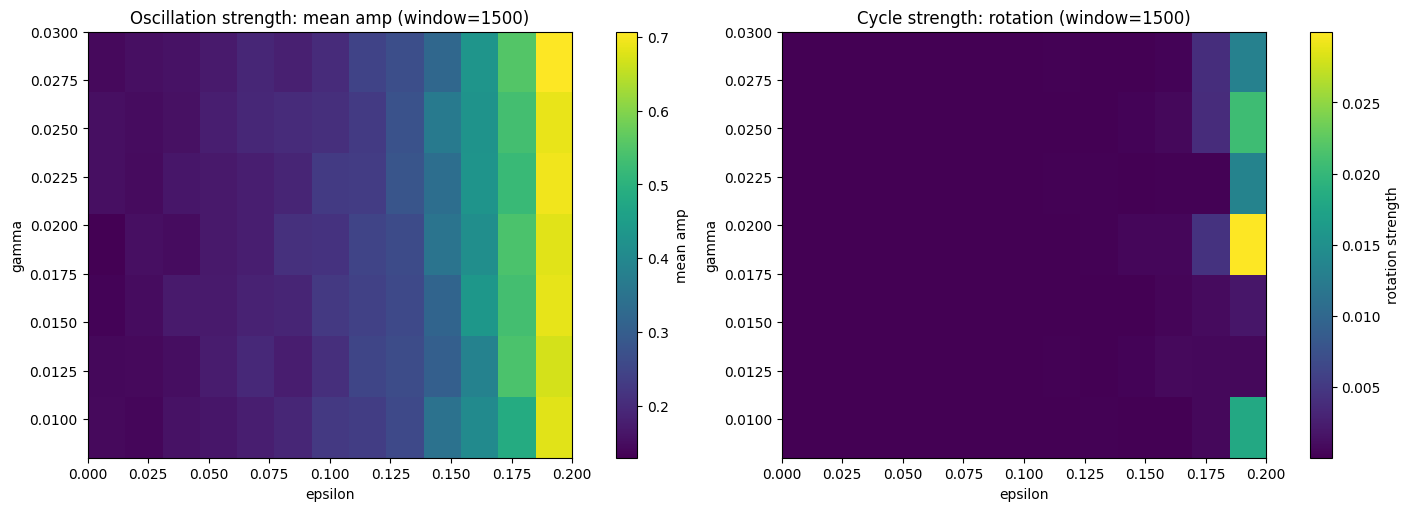

In [38]:
# Heatmap of oscillation/cycle strength over (gamma, epsilon)
import numpy as np

window = GRID_WINDOW if "GRID_WINDOW" in globals() else 200

if not ts_grid:
    raise RuntimeError("ts_grid is empty; run the 2D sweep cell first")

gammas = sorted({g for (g, _e) in ts_grid.keys()})
epsilons = sorted({e for (_g, e) in ts_grid.keys()})
strategies = list(next(iter(ts_grid.values())).proportions.keys())

amp_mat = np.full((len(gammas), len(epsilons)), np.nan, dtype=float)
rot_mat = np.full((len(gammas), len(epsilons)), np.nan, dtype=float)

for i, g in enumerate(gammas):
    for j, e in enumerate(epsilons):
        ts = ts_grid.get((g, e))
        if ts is None:
            continue
        amps = [tail_summary(ts.proportions[s], window=window)["amp"] for s in strategies]
        amp_mat[i, j] = float(np.nanmean(amps))
        rot_mat[i, j] = float(rotation_strength(ts, window=window))

# 精簡輸出：只列 top-k 熱點，避免整張 grid stdout 太大
K = 12
pairs: list[tuple[float, float, float, float]] = []  # (rot, gamma, eps, amp)
for i, g in enumerate(gammas):
    for j, e in enumerate(epsilons):
        rot = float(rot_mat[i, j])
        if not np.isfinite(rot):
            continue
        pairs.append((rot, float(g), float(e), float(amp_mat[i, j])))
pairs.sort(reverse=True, key=lambda t: t[0])

print(f"top-{min(K, len(pairs))} by rotation (window={window}):")
for rot, g, e, amp in pairs[:K]:
    print(f"  gamma={g:g} eps={e:g} rot={rot:.6g} amp={amp:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Left: amplitude heatmap
im0 = axes[0].imshow(
    amp_mat,
    aspect="auto",
    origin="lower",
    extent=[min(epsilons), max(epsilons), min(gammas), max(gammas)],
)
axes[0].set_title(f"Oscillation strength: mean amp (window={window})")
axes[0].set_xlabel("epsilon")
axes[0].set_ylabel("gamma")
fig.colorbar(im0, ax=axes[0], label="mean amp")

# Right: rotation/circulation heatmap
im1 = axes[1].imshow(
    rot_mat,
    aspect="auto",
    origin="lower",
    extent=[min(epsilons), max(epsilons), min(gammas), max(gammas)],
)
axes[1].set_title(f"Cycle strength: rotation (window={window})")
axes[1].set_xlabel("epsilon")
axes[1].set_ylabel("gamma")
fig.colorbar(im1, ax=axes[1], label="rotation strength")

plt.show()

validation points (from top rotation):
  gamma=0.015 eps=0.2 rot@grid=0.0299842 amp@grid=0.6813
  gamma=0.025 eps=0.2 rot@grid=0.0206392 amp@grid=0.6880
  gamma=0.008 eps=0.2 rot@grid=0.0180692 amp@grid=0.6820


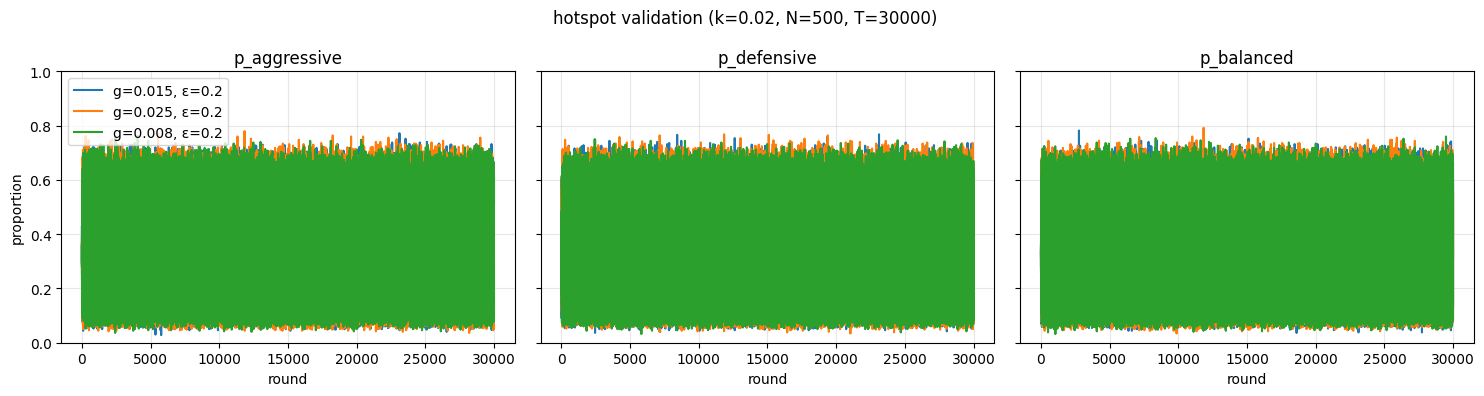

window=8000

[g=0.015, ε=0.2] rounds=30000
  p_aggressive mean=0.333 std=0.197 amp=0.732
  p_defensive  mean=0.333 std=0.197 amp=0.726
  p_balanced   mean=0.333 std=0.197 amp=0.706
  avg_reward   mean=6.485 std=14.244 amp=76.454
  rotation    0.003052

[g=0.025, ε=0.2] rounds=30000
  p_aggressive mean=0.333 std=0.198 amp=0.720
  p_defensive  mean=0.333 std=0.197 amp=0.706
  p_balanced   mean=0.333 std=0.197 amp=0.714
  avg_reward   mean=9.961 std=13.553 amp=75.027
  rotation    0.012690

[g=0.008, ε=0.2] rounds=30000
  p_aggressive mean=0.333 std=0.196 amp=0.688
  p_defensive  mean=0.333 std=0.196 amp=0.708
  p_balanced   mean=0.334 std=0.196 amp=0.714
  avg_reward   mean=14.474 std=12.582 amp=68.136
  rotation    0.017130


In [39]:
# 熱點長回合驗證：把 rotation top-3 的點拉長時間，看是否出現穩定週期（而非短窗噪音）
from pathlib import Path

TOP_M = 3
VAL_ROUNDS = 30000
VAL_WINDOW = 8000

if "pairs" not in globals() or not pairs:
    raise RuntimeError("Run the heatmap cell first so `pairs` is available")

hot = pairs[:TOP_M]  # (rot, gamma, eps, amp)
print("validation points (from top rotation):")
for rot, g, e, amp in hot:
    print(f"  gamma={g:g} eps={e:g} rot@grid={rot:.6g} amp@grid={amp:.4f}")

out_dir = Path("outputs") / "sweeps" / "hotspot_validation"
out_dir.mkdir(parents=True, exist_ok=True)

ts_map_val: dict[str, TimeSeries] = {}
for _rot, g, e, _amp in hot:
    out_csv = out_dir / (
        f"val_g_{_fmt_float_for_filename(g)}"
        f"_eps_{_fmt_float_for_filename(e)}"
        f"_k_{_fmt_float_for_filename(GRID_K)}"
        f"_N_{GRID_N_PLAYERS}_T_{VAL_ROUNDS}.csv"
    )
    run_once_to_csv(
        gamma=g,
        epsilon=e,
        selection_strength=GRID_K,
        rounds=VAL_ROUNDS,
        players=GRID_N_PLAYERS,
        out_csv=out_csv,
        quiet=True,
    )
    ts_map_val[f"g={g:g}, ε={e:g}"] = load_timeseries_csv(out_csv)

# 疊圖：比例時間序列（每策略一張子圖）
strategies = list(next(iter(ts_map_val.values())).proportions.keys())
fig, axs = plt.subplots(1, len(strategies), figsize=(5 * len(strategies), 4), sharey=True)
if len(strategies) == 1:
    axs = [axs]

for i, s in enumerate(strategies):
    ax = axs[i]
    for label, ts in ts_map_val.items():
        ax.plot(ts.rounds, ts.proportions[s], label=label)
    ax.set_title(f"p_{s}")
    ax.set_xlabel("round")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
axs[0].set_ylabel("proportion")
axs[0].legend()
plt.suptitle(f"hotspot validation (k={GRID_K:g}, N={GRID_N_PLAYERS}, T={VAL_ROUNDS})")
plt.tight_layout()
plt.show()

print_dynamics_summary(ts_map_val, window=VAL_WINDOW)

In [36]:
# 補一個最省時的檢查：固定最亮點，掃 k 看 rotation 是否變成「一致方向」的循環
from pathlib import Path

FIX_G = 0.03
FIX_E = 0.16
K_LIST = [0.005, 0.02, 0.05]
K_ROUNDS = 30000
K_WINDOW = 8000

def signed_rotation(ts: TimeSeries, *, window: int = 200) -> float:
    # Same embedding as rotation_strength, but keep sign (direction).
    for key in ("aggressive", "defensive", "balanced"):
        if key not in ts.proportions:
            return float("nan")
    pA = ts.proportions["aggressive"]
    pD = ts.proportions["defensive"]
    pB = ts.proportions["balanced"]
    if len(ts.rounds) < 2:
        return float("nan")
    start = max(0, len(ts.rounds) - window)
    pA = pA[start:]
    pD = pD[start:]
    pB = pB[start:]
    sqrt3 = math.sqrt(3.0)
    xs: list[float] = []
    ys: list[float] = []
    for a, d, b in zip(pA, pD, pB):
        xs.append(float(d) + 0.5 * float(b))
        ys.append((sqrt3 / 2.0) * float(b))
    if len(xs) < 2:
        return float("nan")
    area2 = 0.0
    for x0, y0, x1, y1 in zip(xs[:-1], ys[:-1], xs[1:], ys[1:]):
        area2 += (x0 * y1 - y0 * x1)
    return area2 / max(1, (len(xs) - 1))

out_dir = Path("outputs") / "sweeps" / "k_sweep_hotspot"
out_dir.mkdir(parents=True, exist_ok=True)

ts_map_khot: dict[str, TimeSeries] = {}
for k in K_LIST:
    out_csv = out_dir / (
        f"khot_g_{_fmt_float_for_filename(FIX_G)}"
        f"_eps_{_fmt_float_for_filename(FIX_E)}"
        f"_k_{_fmt_float_for_filename(k)}"
        f"_N_{GRID_N_PLAYERS}_T_{K_ROUNDS}.csv"
    )
    run_once_to_csv(
        gamma=FIX_G,
        epsilon=FIX_E,
        selection_strength=k,
        rounds=K_ROUNDS,
        players=GRID_N_PLAYERS,
        out_csv=out_csv,
        quiet=True,
    )
    ts_map_khot[f"k={k:g}"] = load_timeseries_csv(out_csv)

print(f"k sweep at (gamma={FIX_G:g}, eps={FIX_E:g}), N={GRID_N_PLAYERS}, T={K_ROUNDS}, window={K_WINDOW}")
for label, ts in ts_map_khot.items():
    rot_abs = rotation_strength(ts, window=K_WINDOW)
    rot_sgn = signed_rotation(ts, window=K_WINDOW)
    print(f"  {label:<8} rot_abs={rot_abs:.6g} rot_signed={rot_sgn:.6g}")

print_dynamics_summary(ts_map_khot, window=K_WINDOW)

k sweep at (gamma=0.03, eps=0.16), N=500, T=30000, window=8000
  k=0.005  rot_abs=8.41882e-07 rot_signed=-8.41882e-07
  k=0.02   rot_abs=0.000130529 rot_signed=-0.000130529
  k=0.05   rot_abs=0.123272 rot_signed=0.123272
window=8000

[k=0.005] rounds=30000
  p_aggressive mean=0.333 std=0.022 amp=0.176
  p_defensive  mean=0.334 std=0.022 amp=0.148
  p_balanced   mean=0.333 std=0.021 amp=0.160
  avg_reward   mean=5.001 std=0.138 amp=1.673
  rotation    0.000001

[k=0.02] rounds=30000
  p_aggressive mean=0.333 std=0.054 amp=0.380
  p_defensive  mean=0.333 std=0.054 amp=0.368
  p_balanced   mean=0.333 std=0.054 amp=0.356
  avg_reward   mean=4.966 std=0.874 amp=11.809
  rotation    0.000131

[k=0.05] rounds=30000
  p_aggressive mean=0.334 std=0.376 amp=1.000
  p_defensive  mean=0.333 std=0.376 amp=1.000
  p_balanced   mean=0.333 std=0.376 amp=1.000
  avg_reward   mean=36.985 std=21.184 amp=158.227
  rotation    0.123272


### 6.2 ε 邊界 refinement：用 rotation vs ε 定位 ε_c(γ)

> 固定 `k=0.02`（已確認在此 regime 才會出現強環流），針對 `ε∈[0.16, 0.20]` 做細掃，挑幾個代表 `γ` 畫出 `rotation(ε)`，用閾值抓出粗略臨界點。

refine: |G|=3 |E|=9 sims=27 (T=6000, N=500, k=0.02, window=1500)

Estimated epsilon_c(g) using ROT_CUTOFF= 0.001
  gamma=0.01 -> eps_c=0.17
  gamma=0.015 -> eps_c=0.175
  gamma=0.02 -> eps_c=0.18


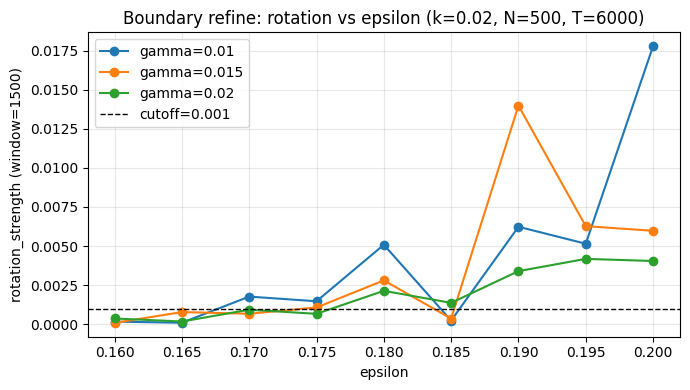

In [40]:
# 1D refinement：rotation vs epsilon（固定 k=0.02）
import numpy as np

REF_GAMMAS = [0.01, 0.015, 0.02]
REF_EPSILONS = [round(x, 3) for x in np.arange(0.16, 0.2001, 0.005)]
REF_K = 0.02
REF_N_PLAYERS = 500
REF_N_ROUNDS = 6000
REF_WINDOW = 1500

ROT_CUTOFF = 1e-3  # 粗略判斷「有結構性環流」的閾值；可視結果再調整

# signed_rotation 可能已在前面 cell 定義；若沒有，這裡補上
if "signed_rotation" not in globals():
    def signed_rotation(ts: TimeSeries, *, window: int = 200) -> float:
        for key in ("aggressive", "defensive", "balanced"):
            if key not in ts.proportions:
                return float("nan")
        pA = ts.proportions["aggressive"]
        pD = ts.proportions["defensive"]
        pB = ts.proportions["balanced"]
        if len(ts.rounds) < 2:
            return float("nan")
        start = max(0, len(ts.rounds) - window)
        pA = pA[start:]
        pD = pD[start:]
        pB = pB[start:]
        sqrt3 = math.sqrt(3.0)
        xs: list[float] = []
        ys: list[float] = []
        for a, d, b in zip(pA, pD, pB):
            xs.append(float(d) + 0.5 * float(b))
            ys.append((sqrt3 / 2.0) * float(b))
        if len(xs) < 2:
            return float("nan")
        area2 = 0.0
        for x0, y0, x1, y1 in zip(xs[:-1], ys[:-1], xs[1:], ys[1:]):
            area2 += (x0 * y1 - y0 * x1)
        return area2 / max(1, (len(xs) - 1))

out_dir = Path("outputs") / "sweeps" / "epsilon_boundary_refine"
out_dir.mkdir(parents=True, exist_ok=True)

rot_abs_map: dict[tuple[float, float], float] = {}
rot_sgn_map: dict[tuple[float, float], float] = {}
amp_map: dict[tuple[float, float], float] = {}

print(f"refine: |G|={len(REF_GAMMAS)} |E|={len(REF_EPSILONS)} sims={len(REF_GAMMAS)*len(REF_EPSILONS)} (T={REF_N_ROUNDS}, N={REF_N_PLAYERS}, k={REF_K}, window={REF_WINDOW})")
for g in REF_GAMMAS:
    for eps in REF_EPSILONS:
        out_csv = out_dir / (
            f"ref_g_{_fmt_float_for_filename(g)}"
            f"_eps_{_fmt_float_for_filename(eps)}"
            f"_k_{_fmt_float_for_filename(REF_K)}"
            f"_N_{REF_N_PLAYERS}_T_{REF_N_ROUNDS}.csv"
        )
        run_once_to_csv(
            gamma=g,
            epsilon=eps,
            selection_strength=REF_K,
            rounds=REF_N_ROUNDS,
            players=REF_N_PLAYERS,
            out_csv=out_csv,
            quiet=True,
        )
        ts = load_timeseries_csv(out_csv)
        rot_abs_map[(g, eps)] = float(rotation_strength(ts, window=REF_WINDOW))
        rot_sgn_map[(g, eps)] = float(signed_rotation(ts, window=REF_WINDOW))
        amps = [tail_summary(ts.proportions[s], window=REF_WINDOW)["amp"] for s in ts.proportions.keys()]
        amp_map[(g, eps)] = float(np.nanmean(amps))

# 估一條粗略 ε_c(g)：第一次超過 ROT_CUTOFF 的 epsilon
eps_c: dict[float, float | None] = {}
for g in REF_GAMMAS:
    cand = [eps for eps in REF_EPSILONS if rot_abs_map.get((g, eps), 0.0) >= ROT_CUTOFF]
    eps_c[g] = min(cand) if cand else None

print("\nEstimated epsilon_c(g) using ROT_CUTOFF=", ROT_CUTOFF)
for g in REF_GAMMAS:
    print(f"  gamma={g:g} -> eps_c={eps_c[g]}")

# Plot rotation vs epsilon
plt.figure(figsize=(7, 4))
for g in REF_GAMMAS:
    ys = [rot_abs_map[(g, eps)] for eps in REF_EPSILONS]
    plt.plot(REF_EPSILONS, ys, marker="o", label=f"gamma={g:g}")
plt.axhline(ROT_CUTOFF, color="black", linestyle="--", linewidth=1, label=f"cutoff={ROT_CUTOFF:g}")
plt.xlabel("epsilon")
plt.ylabel(f"rotation_strength (window={REF_WINDOW})")
plt.title(f"Boundary refine: rotation vs epsilon (k={REF_K:g}, N={REF_N_PLAYERS}, T={REF_N_ROUNDS})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 可選：如果你想看振幅是否也同步跳變，解除註解以下區塊
# plt.figure(figsize=(7, 4))
# for g in REF_GAMMAS:
#     ys = [amp_map[(g, eps)] for eps in REF_EPSILONS]
#     plt.plot(REF_EPSILONS, ys, marker="o", label=f"gamma={g:g}")
# plt.xlabel("epsilon")
# plt.ylabel(f"mean amp over strategies (window={REF_WINDOW})")
# plt.title(f"Boundary refine: amp vs epsilon (k={REF_K:g}, N={REF_N_PLAYERS}, T={REF_N_ROUNDS})")
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

#### 6.2.1 聚焦 γ=0.015：ε 以 0.002 步長加密 + T=12000

> 目的：釐清先前在 `ε≈0.185` 一帶看起來「掉回去」是否只是 transient / window 效應。

- 固定 `gamma=0.015, k=0.02, N=500`
- `epsilon`：0.165→0.189（step=0.002，包含 0.185）
- `T=12000`，並同時比較 `window=3000` 與 `window=6000` 的 rotation

focus refine: gamma=0.015 |eps|=13 (T=12000, N=500, k=0.02)

estimated eps_c (gamma=0.015) by cutoff 0.001 using W2=6000: 0.183
top-5 by rot_w2:
  eps=0.187 rot_w2=0.00529743 sgn_w2=0.00529743 amp_w2=0.641
  eps=0.185 rot_w2=0.00461724 sgn_w2=-0.00461724 amp_w2=0.593
  eps=0.189 rot_w2=0.00426694 sgn_w2=-0.00426694 amp_w2=0.659
  eps=0.183 rot_w2=0.00407698 sgn_w2=0.00407698 amp_w2=0.617
  eps=0.181 rot_w2=0.000715002 sgn_w2=0.000715002 amp_w2=0.556


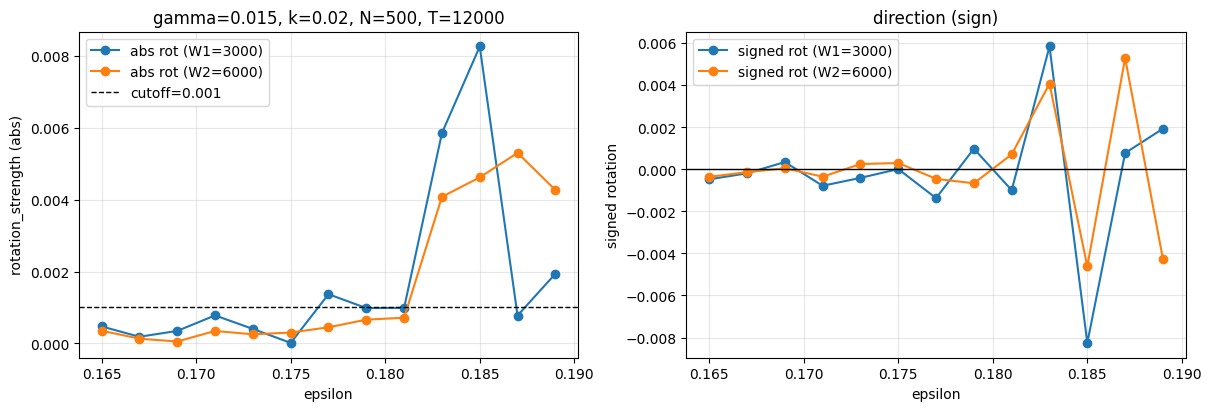

In [41]:
# Focus refine at gamma=0.015
import numpy as np

FOCUS_G = 0.015
FOCUS_EPSILONS = [round(x, 3) for x in np.arange(0.165, 0.1891, 0.002)]  # includes 0.185
FOCUS_K = 0.02
FOCUS_N_PLAYERS = 500
FOCUS_N_ROUNDS = 12000
W1 = 3000
W2 = 6000
CUTOFF = 1e-3

out_dir = Path("outputs") / "sweeps" / "epsilon_refine_g015"
out_dir.mkdir(parents=True, exist_ok=True)

rows: list[dict[str, float]] = []
print(f"focus refine: gamma={FOCUS_G:g} |eps|={len(FOCUS_EPSILONS)} (T={FOCUS_N_ROUNDS}, N={FOCUS_N_PLAYERS}, k={FOCUS_K})")
for eps in FOCUS_EPSILONS:
    out_csv = out_dir / (
        f"g_{_fmt_float_for_filename(FOCUS_G)}"
        f"_eps_{_fmt_float_for_filename(eps)}"
        f"_k_{_fmt_float_for_filename(FOCUS_K)}"
        f"_N_{FOCUS_N_PLAYERS}_T_{FOCUS_N_ROUNDS}.csv"
    )
    run_once_to_csv(
        gamma=FOCUS_G,
        epsilon=eps,
        selection_strength=FOCUS_K,
        rounds=FOCUS_N_ROUNDS,
        players=FOCUS_N_PLAYERS,
        out_csv=out_csv,
        quiet=True,
    )
    ts = load_timeseries_csv(out_csv)
    rot1 = float(rotation_strength(ts, window=W1))
    rot2 = float(rotation_strength(ts, window=W2))
    sgn1 = float(signed_rotation(ts, window=W1))
    sgn2 = float(signed_rotation(ts, window=W2))
    amps = [tail_summary(ts.proportions[s], window=W2)["amp"] for s in ts.proportions.keys()]
    amp = float(np.nanmean(amps))
    rows.append({"eps": float(eps), "rot_w1": rot1, "rot_w2": rot2, "sgn_w1": sgn1, "sgn_w2": sgn2, "amp_w2": amp})

# estimate eps_c by cutoff using W2
eps_c = None
for r in rows:
    if r["rot_w2"] >= CUTOFF:
        eps_c = r["eps"]
        break
print(f"\nestimated eps_c (gamma={FOCUS_G:g}) by cutoff {CUTOFF:g} using W2={W2}: {eps_c}")

# print top points for quick inspection
top = sorted(rows, key=lambda r: r["rot_w2"], reverse=True)[:5]
print("top-5 by rot_w2:")
for r in top:
    print(f"  eps={r['eps']:.3f} rot_w2={r['rot_w2']:.6g} sgn_w2={r['sgn_w2']:.6g} amp_w2={r['amp_w2']:.3f}")

# plot
xs = [r["eps"] for r in rows]
rot_w1 = [r["rot_w1"] for r in rows]
rot_w2 = [r["rot_w2"] for r in rows]
sgn_w1 = [r["sgn_w1"] for r in rows]
sgn_w2 = [r["sgn_w2"] for r in rows]

fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axs[0].plot(xs, rot_w1, marker="o", label=f"abs rot (W1={W1})")
axs[0].plot(xs, rot_w2, marker="o", label=f"abs rot (W2={W2})")
axs[0].axhline(CUTOFF, color="black", linestyle="--", linewidth=1, label=f"cutoff={CUTOFF:g}")
axs[0].set_xlabel("epsilon")
axs[0].set_ylabel("rotation_strength (abs)")
axs[0].set_title(f"gamma={FOCUS_G:g}, k={FOCUS_K:g}, N={FOCUS_N_PLAYERS}, T={FOCUS_N_ROUNDS}")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].plot(xs, sgn_w1, marker="o", label=f"signed rot (W1={W1})")
axs[1].plot(xs, sgn_w2, marker="o", label=f"signed rot (W2={W2})")
axs[1].axhline(0.0, color="black", linewidth=1)
axs[1].set_xlabel("epsilon")
axs[1].set_ylabel("signed rotation")
axs[1].set_title("direction (sign)")
axs[1].grid(True, alpha=0.3)
axs[1].legend()

plt.show()

dense repeats: gamma=0.015, k=0.02, N=500, T=12000, window=8000, eps=[0.18,0.19] step=0.001 (|eps|=11), repeats=9

Threshold definitions:
  ROT_CUTOFF=0.001, ACTIVE_THRESH=0.8, SIGN_THRESH=0.8
  eps_c_amp (active_rate & mean(abs rot)): 0.189
  eps_c_dir (+ direction consistency):     None

Per-epsilon summary:
  eps    abs_mean   abs_std    active_rate  sign_consis  dom_sign   amp_ok dir_ok
  0.180  0.00117895  0.0012     0.44        0.75       -1        0     0
  0.181  0.000929323  0.00094     0.44        0.75       -1        0     0
  0.182  0.000922354  0.00062     0.33        0.67       +1        0     0
  0.183  0.0014227  0.00076     0.67        0.83       -1        0     0
  0.184  0.00132391  0.0012     0.44        0.75       +1        0     0
  0.185  0.00166284  0.001     0.78        0.71       -1        0     0
  0.186  0.00166365  0.00088     0.78        0.86       -1        0     0
  0.187  0.00221169  0.0017     0.67        0.67       -1        0     0
  0.188  0.0016018

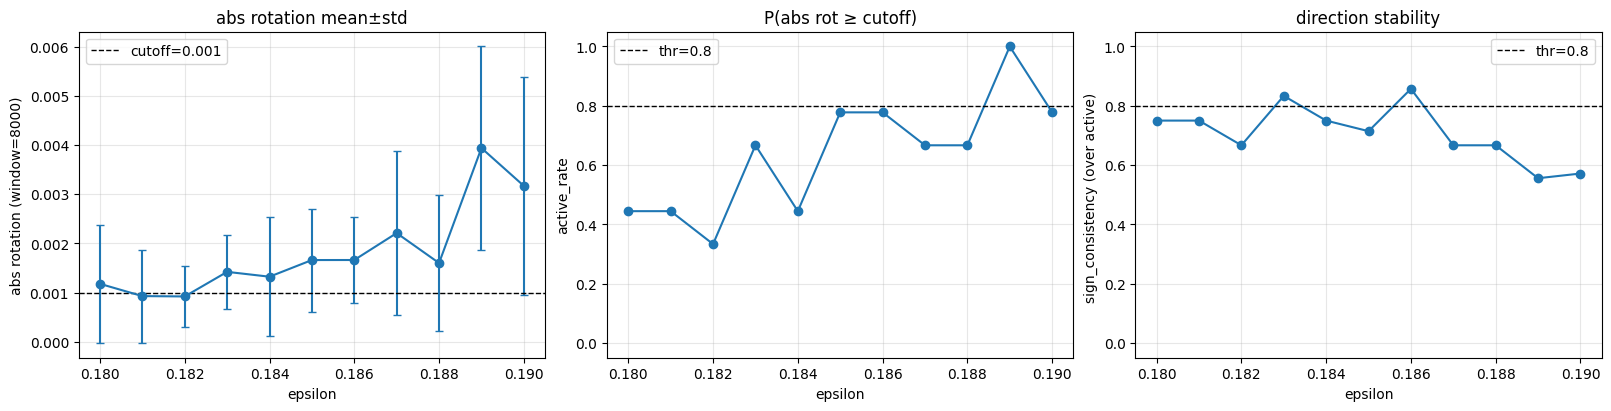

In [45]:
# Repeats near the boundary (thorough): epsilon sweep × repeats
# Goal: estimate two thresholds
#   eps_c_amp: active_rate high AND mean(abs rot) above cutoff
#   eps_c_dir: additionally direction (signed rot) is consistent

import random
import numpy as np

REPEAT_G = 0.015
REPEAT_K = 0.02
REPEAT_N = 500
REPEAT_T = 12000
REPEAT_W = 8000

EPS_MIN = 0.180
EPS_MAX = 0.190
EPS_STEP = 0.001
REPEAT_EPS = [round(float(x), 3) for x in np.arange(EPS_MIN, EPS_MAX + 1e-12, EPS_STEP)]

REPEATS = 9
BASE_SEED = 20260301

ROT_CUTOFF = 1e-3
ACTIVE_THRESH = 0.80
SIGN_THRESH = 0.80

out_dir = Path("outputs") / "sweeps" / "epsilon_repeats_g015_dense"
out_dir.mkdir(parents=True, exist_ok=True)


def _signed_rotation_fallback(ts: TimeSeries, *, window: int) -> float:
    # Signed version of rotation_strength(): same embedding + signed area per step.
    for key in ("aggressive", "defensive", "balanced"):
        if key not in ts.proportions:
            return float("nan")

    pA = ts.proportions["aggressive"]
    pD = ts.proportions["defensive"]
    pB = ts.proportions["balanced"]

    if len(ts.rounds) < 2:
        return float("nan")
    start = max(0, len(ts.rounds) - window)
    pA = pA[start:]
    pD = pD[start:]
    pB = pB[start:]

    sqrt3 = math.sqrt(3.0)
    xs: list[float] = []
    ys: list[float] = []
    for a, d, b in zip(pA, pD, pB):
        x = float(d) + 0.5 * float(b)
        y = (sqrt3 / 2.0) * float(b)
        xs.append(x)
        ys.append(y)

    if len(xs) < 2:
        return float("nan")

    area2 = 0.0
    for x0, y0, x1, y1 in zip(xs[:-1], ys[:-1], xs[1:], ys[1:]):
        area2 += (x0 * y1 - y0 * x1)
    return area2 / max(1, (len(xs) - 1))


# Use existing signed_rotation if present; otherwise use fallback.
_signed_rot = globals().get("signed_rotation", None)
if not callable(_signed_rot):
    _signed_rot = lambda ts, window: _signed_rotation_fallback(ts, window=window)

print(
    "dense repeats: "
    f"gamma={REPEAT_G:g}, k={REPEAT_K:g}, N={REPEAT_N}, T={REPEAT_T}, window={REPEAT_W}, "
    f"eps=[{EPS_MIN:g},{EPS_MAX:g}] step={EPS_STEP:g} (|eps|={len(REPEAT_EPS)}), repeats={REPEATS}"
)

results: list[dict[str, float]] = []

for eps in REPEAT_EPS:
    for rep in range(REPEATS):
        seed = BASE_SEED + int(round(eps * 1000)) * 100 + rep
        random.seed(seed)
        np.random.seed(seed)

        out_csv = out_dir / (
            f"g_{_fmt_float_for_filename(REPEAT_G)}"
            f"_eps_{_fmt_float_for_filename(eps)}"
            f"_k_{_fmt_float_for_filename(REPEAT_K)}"
            f"_N_{REPEAT_N}_T_{REPEAT_T}"
            f"_rep_{rep}_seed_{seed}.csv"
        )

        if not out_csv.exists():
            run_once_to_csv(
                gamma=REPEAT_G,
                epsilon=eps,
                selection_strength=REPEAT_K,
                rounds=REPEAT_T,
                players=REPEAT_N,
                out_csv=out_csv,
                quiet=True,
            )

        ts = load_timeseries_csv(out_csv)
        rot_abs = float(rotation_strength(ts, window=REPEAT_W))
        rot_sgn = float(_signed_rot(ts, window=REPEAT_W))
        results.append(
            {
                "eps": float(eps),
                "rep": float(rep),
                "seed": float(seed),
                "rot_abs": rot_abs,
                "rot_sgn": rot_sgn,
            }
        )

# Aggregate by epsilon
summary: list[dict[str, float]] = []

for eps in REPEAT_EPS:
    rows = [r for r in results if abs(r["eps"] - eps) < 1e-12]
    rot_abs_list = [r["rot_abs"] for r in rows]
    rot_sgn_list = [r["rot_sgn"] for r in rows]

    active_idx = [i for i, a in enumerate(rot_abs_list) if math.isfinite(a) and a >= ROT_CUTOFF]
    active_rate = float(len(active_idx) / len(rows)) if rows else float("nan")

    if active_idx:
        signs = [1 if rot_sgn_list[i] > 0 else (-1 if rot_sgn_list[i] < 0 else 0) for i in active_idx]
        pos = sum(1 for s in signs if s > 0)
        neg = sum(1 for s in signs if s < 0)
        # ignore exact zeros for direction; if all zeros, mark nan
        denom = pos + neg
        if denom > 0:
            sign_consistency = max(pos, neg) / denom
            dominant_sign = 1.0 if pos >= neg else -1.0
        else:
            sign_consistency = float("nan")
            dominant_sign = float("nan")
    else:
        sign_consistency = float("nan")
        dominant_sign = float("nan")

    rot_abs_mean = float(np.nanmean(rot_abs_list))
    rot_abs_std = float(np.nanstd(rot_abs_list, ddof=0))

    amp_ok = (active_rate >= ACTIVE_THRESH) and (math.isfinite(rot_abs_mean) and rot_abs_mean >= ROT_CUTOFF)
    dir_ok = amp_ok and (math.isfinite(sign_consistency) and sign_consistency >= SIGN_THRESH)

    summary.append(
        {
            "eps": float(eps),
            "rot_abs_mean": rot_abs_mean,
            "rot_abs_std": rot_abs_std,
            "active_rate": active_rate,
            "sign_consistency": float(sign_consistency),
            "dominant_sign": float(dominant_sign),
            "amp_ok": 1.0 if amp_ok else 0.0,
            "dir_ok": 1.0 if dir_ok else 0.0,
        }
    )

# Estimate eps_c under the two definitions
summary_sorted = sorted(summary, key=lambda s: s["eps"])

def _first_eps_where(key: str) -> float | None:
    for s in summary_sorted:
        if s.get(key, 0.0) >= 1.0:
            return float(s["eps"])
    return None

eps_c_amp = _first_eps_where("amp_ok")
eps_c_dir = _first_eps_where("dir_ok")

print("\nThreshold definitions:")
print(f"  ROT_CUTOFF={ROT_CUTOFF:g}, ACTIVE_THRESH={ACTIVE_THRESH:g}, SIGN_THRESH={SIGN_THRESH:g}")
print(f"  eps_c_amp (active_rate & mean(abs rot)): {eps_c_amp}")
print(f"  eps_c_dir (+ direction consistency):     {eps_c_dir}")

print("\nPer-epsilon summary:")
print("  eps    abs_mean   abs_std    active_rate  sign_consis  dom_sign   amp_ok dir_ok")
for s in summary_sorted:
    sc = s["sign_consistency"]
    ds = s["dominant_sign"]
    print(
        f"  {s['eps']:.3f}  {s['rot_abs_mean']:.6g}  {s['rot_abs_std']:.2g}     "
        f"{s['active_rate']:.2f}        "
        f"{sc if math.isfinite(sc) else float('nan'):.2f}       "
        f"{ds if math.isfinite(ds) else float('nan'):+.0f}        "
        f"{int(s['amp_ok'])}     {int(s['dir_ok'])}"
    )

# Plots: abs rotation (mean±std), active_rate, sign_consistency
xs = [s["eps"] for s in summary_sorted]
abs_mean = [s["rot_abs_mean"] for s in summary_sorted]
abs_std = [s["rot_abs_std"] for s in summary_sorted]
active_rate = [s["active_rate"] for s in summary_sorted]
sign_cons = [s["sign_consistency"] for s in summary_sorted]

a = np.array(active_rate, dtype=float)

fig, axs = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
axs[0].errorbar(xs, abs_mean, yerr=abs_std, marker="o", capsize=3)
axs[0].axhline(ROT_CUTOFF, color="black", linestyle="--", linewidth=1, label=f"cutoff={ROT_CUTOFF:g}")
axs[0].set_xlabel("epsilon")
axs[0].set_ylabel(f"abs rotation (window={REPEAT_W})")
axs[0].set_title("abs rotation mean±std")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].plot(xs, active_rate, marker="o")
axs[1].axhline(ACTIVE_THRESH, color="black", linestyle="--", linewidth=1, label=f"thr={ACTIVE_THRESH:g}")
axs[1].set_ylim(-0.05, 1.05)
axs[1].set_xlabel("epsilon")
axs[1].set_ylabel("active_rate")
axs[1].set_title("P(abs rot ≥ cutoff)")
axs[1].grid(True, alpha=0.3)
axs[1].legend()

axs[2].plot(xs, sign_cons, marker="o")
axs[2].axhline(SIGN_THRESH, color="black", linestyle="--", linewidth=1, label=f"thr={SIGN_THRESH:g}")
axs[2].set_ylim(-0.05, 1.05)
axs[2].set_xlabel("epsilon")
axs[2].set_ylabel("sign_consistency (over active) ")
axs[2].set_title("direction stability")
axs[2].grid(True, alpha=0.3)
axs[2].legend()

plt.show()

## 快速看「模擬長什麼樣」：單次 run 的時間序列圖

這一段會：
1) 用同一組參數快速掃幾個 seed，挑出最像 Level3 的 seed
2) 畫出 `w_*`（weights）與 `p_*`（strategy distribution）時間序列
3) 印出 `cycle_level / stage3_score / env_gamma` 方便對照

project_root: /home/user/personality-dungeon
seed diagnostics (sorted):
seed= 2  level=3  s3_score=0.578  env_gamma=-1.84e-05  r2=0.000  n_peaks=310
seed= 3  level=3  s3_score=0.574  env_gamma=-2.13e-05  r2=0.000  n_peaks=310
seed= 5  level=3  s3_score=0.572  env_gamma=-4.88e-05  r2=0.001  n_peaks=308
seed= 4  level=3  s3_score=0.570  env_gamma=-3.80e-05  r2=0.001  n_peaks=308
seed= 6  level=3  s3_score=0.570  env_gamma=-9.26e-05  r2=0.004  n_peaks=308
seed= 0  level=3  s3_score=0.569  env_gamma=+2.39e-05  r2=0.000  n_peaks=307
seed= 1  level=3  s3_score=0.568  env_gamma=+1.79e-05  r2=0.000  n_peaks=309
seed= 7  level=3  s3_score=0.565  env_gamma=-9.93e-05  r2=0.005  n_peaks=311
seed= 8  level=3  s3_score=0.564  env_gamma=-5.99e-05  r2=0.002  n_peaks=311
seed= 9  level=3  s3_score=0.557  env_gamma=-4.85e-05  r2=0.001  n_peaks=316

Chosen seed: SeedDiag(seed=2, level=3, stage3_score=0.5778275475923852, env_gamma=-1.8404821823576072e-05, env_gamma_r2=0.00019690949443607053, env_gamma_n_p

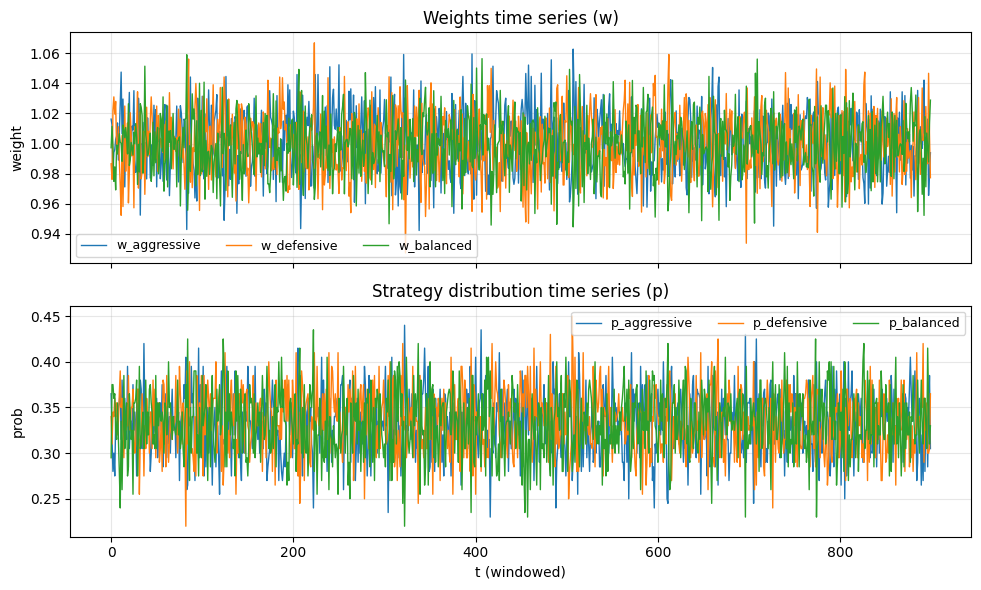

In [2]:
from __future__ import annotations

import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List

import matplotlib.pyplot as plt

# Ensure repo root is importable (so `analysis.*` / `simulation.*` work in notebooks).
project_root = Path.cwd().resolve()
if not (project_root / "simulation").exists():
    if (project_root.parent / "simulation").exists():
        project_root = project_root.parent.resolve()
sys.path.insert(0, str(project_root))
print("project_root:", project_root)

from analysis.cycle_metrics import classify_cycle_level
from analysis.decay_rate import estimate_decay_gamma
from simulation.run_simulation import SimConfig, simulate_series_window


@dataclass(frozen=True)
class SeedDiag:
    seed: int
    level: int
    stage3_score: float
    env_gamma: float
    env_gamma_r2: float
    env_gamma_n_peaks: int


def _metric_kwargs(*, series: str) -> dict:
    # Align with the thresholds used in the rho_curve sweeps (tweak here if needed).
    return {
        "amplitude_threshold": 0.005,
        "min_lag": 2,
        "max_lag": 500,
        "corr_threshold": 0.05,
        "eta": 0.55,
        "min_turn_strength": 0.0,
        "normalize_for_phase": (series == "w"),
        "stage3_method": "turning",
        "phase_smoothing": 1,
        "stage3_window": None,
        "stage3_step": 20,
        "stage3_quantile": 0.75,
    }


def run_one_series(*, seed: int, series: str) -> Dict[str, List[float]]:
    cfg = SimConfig(
        n_players=200,
        n_rounds=3000,
        seed=int(seed),
        payoff_mode="matrix_ab",
        popularity_mode="sampled",
        evolution_mode="sampled",
        payoff_lag=1,
        gamma=0.1,
        epsilon=0.0,
        a=0.4,
        b=0.2425406997,
        init_bias=0.0,
        selection_strength=1.04,
        out_csv=None,
    )
    burn_in = int(round(cfg.n_rounds * 0.25))
    tail = 900
    return simulate_series_window(cfg, series=series, burn_in=burn_in, tail=tail)


def diagnose_seed(seed: int) -> SeedDiag:
    series_map = run_one_series(seed=seed, series="w")
    res = classify_cycle_level(series_map, burn_in=0, tail=None, **_metric_kwargs(series="w"))
    fit = estimate_decay_gamma(series_map, series_kind="w")
    env_gamma = float(fit.gamma) if fit is not None else 0.0
    env_gamma_r2 = float(fit.r2) if fit is not None else 0.0
    env_gamma_n_peaks = int(fit.n_peaks) if fit is not None else 0
    stage3_score = float(res.stage3.score) if res.stage3 is not None else 0.0
    return SeedDiag(
        seed=int(seed),
        level=int(res.level),
        stage3_score=float(stage3_score),
        env_gamma=float(env_gamma),
        env_gamma_r2=float(env_gamma_r2),
        env_gamma_n_peaks=int(env_gamma_n_peaks),
    )


# 1) 小掃幾個 seed，挑一個最像 Level3 的來畫
seed_list = list(range(10))
diags = [diagnose_seed(sd) for sd in seed_list]
diags_sorted = sorted(diags, key=lambda d: (d.level, d.stage3_score), reverse=True)
best = diags_sorted[0]
print("seed diagnostics (sorted):")
for d in diags_sorted:
    print(
        f"seed={d.seed:2d}  level={d.level}  s3_score={d.stage3_score:.3f}  "
        f"env_gamma={d.env_gamma:+.2e}  r2={d.env_gamma_r2:.3f}  n_peaks={d.env_gamma_n_peaks}"
    )
print("\nChosen seed:", best)


# 2) 用挑到的 seed 畫 w/p 時間序列
w_map = run_one_series(seed=best.seed, series="w")
p_map = run_one_series(seed=best.seed, series="p")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for name, ys in w_map.items():
    axes[0].plot(ys, label=f"w_{name}", linewidth=1)
axes[0].set_title("Weights time series (w)")
axes[0].set_ylabel("weight")
axes[0].grid(True, alpha=0.3)
axes[0].legend(ncol=3, fontsize=9)

for name, ys in p_map.items():
    axes[1].plot(ys, label=f"p_{name}", linewidth=1)
axes[1].set_title("Strategy distribution time series (p)")
axes[1].set_ylabel("prob")
axes[1].set_xlabel("t (windowed)")
axes[1].grid(True, alpha=0.3)
axes[1].legend(ncol=3, fontsize=9)

plt.tight_layout()
plt.show()

## （可選）看更乾淨的旋轉：`mean_field`（確定性、無抽樣噪音）

`sampled` 會有有限族群噪音，所以時間序列常看起來像抖動。
如果要直觀地看到「相位旋轉」的形狀，可以切到 `evolution_mode=mean_field`（同樣用 payoff lag）。

mean_field cycle_level: 3
stage3_score: 1.0
env_gamma (from w): 5.642110486996778e-06


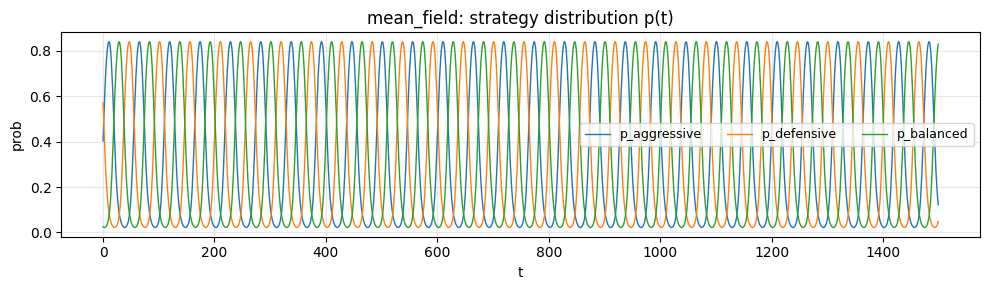

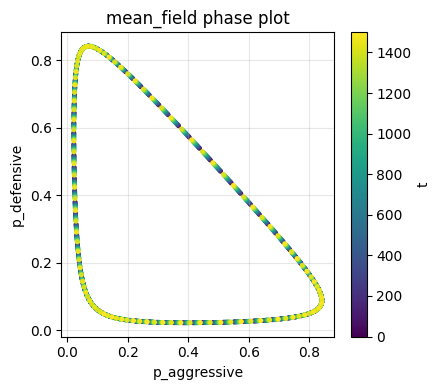

In [3]:
import numpy as np

# mean_field 會在均勻點卡住，所以給一點點 init_bias 破對稱
cfg_mf = SimConfig(
    n_players=200,
    n_rounds=2500,
    seed=0,
    payoff_mode="matrix_ab",
    popularity_mode="sampled",
    evolution_mode="mean_field",
    payoff_lag=1,
    gamma=0.1,
    epsilon=0.0,
    a=0.4,
    b=0.2425406997,
    init_bias=0.01,
    selection_strength=0.9,
    out_csv=None,
 )

p_map_mf = simulate_series_window(cfg_mf, series="p", burn_in=0, tail=1500)
w_map_mf = simulate_series_window(cfg_mf, series="w", burn_in=0, tail=1500)

# 診斷一下 cycle level（用 p 比較直覺）
res_mf = classify_cycle_level(p_map_mf, burn_in=0, tail=None, **_metric_kwargs(series="p"))
fit_mf = estimate_decay_gamma(w_map_mf, series_kind="w")
print("mean_field cycle_level:", res_mf.level)
if res_mf.stage3 is not None:
    print("stage3_score:", res_mf.stage3.score)
print("env_gamma (from w):", 0.0 if fit_mf is None else float(fit_mf.gamma))

# 圖 1：時間序列（p）
plt.figure(figsize=(10, 3))
for name, ys in p_map_mf.items():
    plt.plot(ys, label=f"p_{name}", linewidth=1)
plt.title("mean_field: strategy distribution p(t)")
plt.xlabel("t")
plt.ylabel("prob")
plt.grid(True, alpha=0.3)
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

# 圖 2：相圖（p_aggressive vs p_defensive），用時間上色
a_name, d_name = "aggressive", "defensive"
x = np.array(p_map_mf[a_name], dtype=float)
y = np.array(p_map_mf[d_name], dtype=float)
t = np.arange(len(x))

plt.figure(figsize=(4.5, 4.0))
sc = plt.scatter(x, y, c=t, s=6, cmap="viridis")
plt.colorbar(sc, label="t")
plt.xlabel(f"p_{a_name}")
plt.ylabel(f"p_{d_name}")
plt.title("mean_field phase plot")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 看清楚「塞選」：Level 1 / 2 / 3 各挑一個代表 seed（含 2D/3D 相圖）

想法：同一組參數下，有限抽樣噪音會讓不同 seed 落在不同 cycle level。
這格會：
1) 掃一段 seed（必要時也會換幾個 `selection_strength`）
2) 印出每個候選的 `level / stage3_score / amp / corr`
3) 從 Level 1/2/3 各挑一個代表 seed，畫 `p(t)`、2D 相圖，並提供可選的 3D `(p_a,p_d,p_b)` 軌跡（雖然在 $p_a+p_d+p_b=1$ 的平面上，但對照時間顏色仍很直觀）。

theory: k*≈0.500 gives rho≈1.000000; scanning band size=11
k band: 0.38, 0.40, 0.42, 0.44, 0.46, 0.48, 0.50, 0.52, 0.54, 0.56, 0.58
mode=expected/sampled N=200 k=0.380 rho=0.997614 | counts(0/1/2/3)=14/0/0/0
mode=expected/sampled N=200 k=0.400 rho=0.997910 | counts(0/1/2/3)=14/0/0/0
mode=expected/sampled N=200 k=0.420 rho=0.998248 | counts(0/1/2/3)=14/0/0/0
mode=expected/sampled N=200 k=0.440 rho=0.998626 | counts(0/1/2/3)=14/0/0/0
mode=expected/sampled N=200 k=0.460 rho=0.999044 | counts(0/1/2/3)=14/0/0/0
mode=expected/sampled N=200 k=0.480 rho=0.999502 | counts(0/1/2/3)=14/0/0/0
mode=expected/sampled N=200 k=0.500 rho=1.000000 | counts(0/1/2/3)=14/0/0/0
mode=expected/sampled N=200 k=0.520 rho=1.000537 | counts(0/1/2/3)=14/0/0/0
mode=expected/sampled N=200 k=0.540 rho=1.001112 | counts(0/1/2/3)=14/0/0/0
mode=expected/sampled N=200 k=0.560 rho=1.001725 | counts(0/1/2/3)=14/0/0/0
mode=expected/sampled N=200 k=0.580 rho=1.002376 | counts(0/1/2/3)=14/0/0/0
mode=sampled/sampled N=300 k=0.3

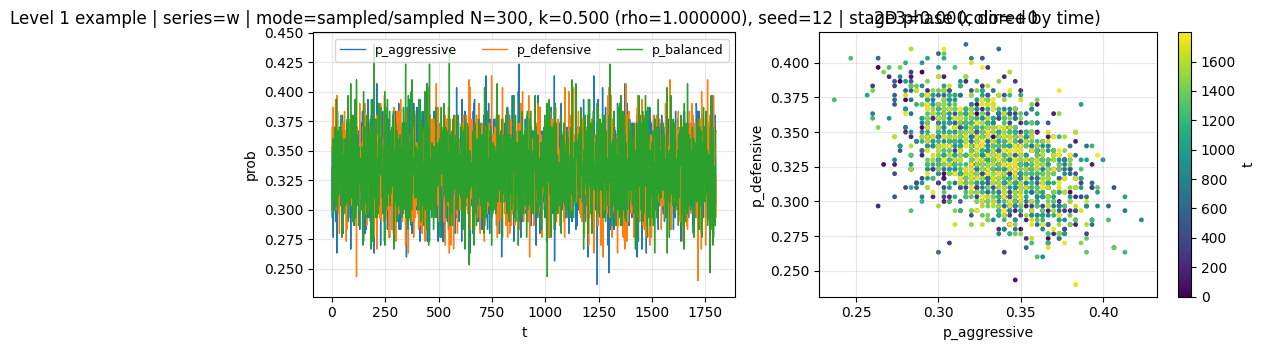

  -> recomputed on DIAG_SERIES: w level: 1 stage3: None


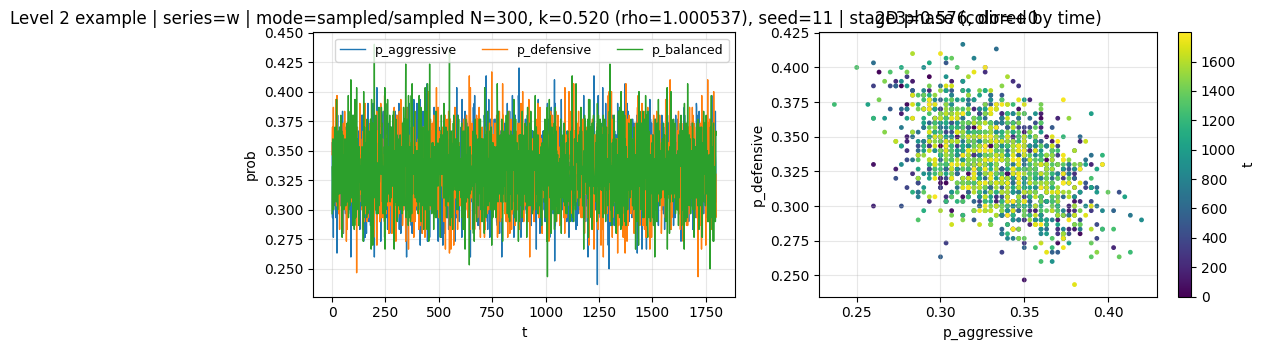

  -> recomputed on DIAG_SERIES: w level: 1 stage3: None


In [9]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

# --- imports: make sure repo root is on sys.path ---
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "simulation").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from simulation.run_simulation import SimConfig, simulate_series_window
from analysis.cycle_metrics import classify_cycle_level
from analysis.jacobian_rotation import lagged_jacobian_at_uniform, summarize_lagged

# --- near-critical search knobs (fast + targeted) ---
# 目標：不要盲掃 k；先用理論 rho(k) 找到 rho≈1 的 near-critical 帶，再在這個帶內掃 seed。
# 同時：分類用 series='w'（和 rho_curve/seed_stability 一致），Stage2 會比用 p(t) 穩定。

# Diagnostics series for classification (align with rho_curve)
DIAG_SERIES = "w"  # 'w' or 'p'
SEEDS_PER_K = 14
SEED_START = 0
SEED_STEP = 1

# Simulation window for diag (match rho_curve shape but lighter)
ROUNDS_FAST = 4000
BURN_IN_FAST = 1000
TAIL_FAST = 600

# Plot window (only for selected reps)
ROUNDS_PLOT = 5000
BURN_IN_PLOT = 1250
TAIL_PLOT = 1800

# Metrics (tuned so Stage2 can pass near rho≈1)
AMP_TH = 0.02
CORR_TH = 0.12
MIN_LAG = 2
MAX_LAG = 500
STAGE3_ETA = 0.6
STAGE3_WINDOW = None
STAGE3_STEP = 20
STAGE3_Q = 0.75

# base payoff params
A = 0.4
B = 0.2425406997
INIT_BIAS = 0.01
STRATS = ("aggressive", "defensive", "balanced")

# search specs (try expected first for lower measurement noise)
SEARCH_SPECS = [
    dict(popularity_mode="expected", evolution_mode="sampled", n_players=200),
    dict(popularity_mode="sampled", evolution_mode="sampled", n_players=300),

]


def _rho(selection_strength: float) -> float:
    rep = lagged_jacobian_at_uniform(a=float(A), b=float(B), selection_strength=float(selection_strength))
    s = summarize_lagged(rep, tol=1e-6)
    return float(s.rho)


def _near_critical_k_band(*, k_min=0.20, k_max=0.90, k_step=0.02, rho_tol=0.0025):
    ks = []
    k = float(k_min)
    while k <= float(k_max) + 1e-12:
        ks.append(float(round(k, 6)))
        k += float(k_step)
    rows = [(kk, _rho(kk)) for kk in ks]
    best_k, best_rho = min(rows, key=lambda r: abs(r[1] - 1.0))
    band = [kk for kk, rr in rows if abs(rr - 1.0) <= float(rho_tol)]
    # If band is empty for numerical reasons, keep a small window around best_k
    if not band:
        band = [best_k - 2 * k_step, best_k - k_step, best_k, best_k + k_step, best_k + 2 * k_step]
        band = [float(kk) for kk in band if float(k_min) <= kk <= float(k_max)]
    return rows, float(best_k), float(best_rho), band


RHO_ROWS, K_STAR, RHO_STAR, K_BAND = _near_critical_k_band()
print(f"theory: k*≈{K_STAR:.3f} gives rho≈{RHO_STAR:.6f}; scanning band size={len(K_BAND)}")
print("k band:", ", ".join(f"{k:.2f}" for k in K_BAND))


@dataclass(frozen=True)
class SeedDiag:
    popularity_mode: str
    evolution_mode: str
    n_players: int
    k: float
    rho: float
    seed: int
    level: int
    stage3_score: float
    stage3_dir: int
    amp_max: float
    corr_max: float


def _classify(series_map: dict[str, list[float]]):
    return classify_cycle_level(
        series_map,
        burn_in=0,
        tail=None,
        strategies=STRATS,
        amplitude_threshold=float(AMP_TH),
        min_lag=int(MIN_LAG),
        max_lag=int(MAX_LAG),
        corr_threshold=float(CORR_TH),
        eta=float(STAGE3_ETA),
        min_turn_strength=0.0,
        normalize_for_phase=bool(DIAG_SERIES == "w"),
        stage3_method="turning",
        phase_smoothing=1,
        stage3_window=(int(STAGE3_WINDOW) if STAGE3_WINDOW is not None else None),
        stage3_step=int(STAGE3_STEP),
        stage3_quantile=float(STAGE3_Q),
    )


def _diag_one(*, popularity_mode: str, evolution_mode: str, n_players: int, k: float, seed: int) -> SeedDiag:
    rho = _rho(float(k))
    cfg = SimConfig(
        n_players=int(n_players),
        n_rounds=int(ROUNDS_FAST),
        seed=int(seed),
        payoff_mode="matrix_ab",
        popularity_mode=str(popularity_mode),
        evolution_mode=str(evolution_mode),
        payoff_lag=1,
        gamma=0.1,
        epsilon=0.0,
        a=float(A),
        b=float(B),
        init_bias=float(INIT_BIAS),
        selection_strength=float(k),
        out_csv=Path(""),
    )
    series_map = simulate_series_window(
        cfg,
        series=str(DIAG_SERIES),
        burn_in=int(BURN_IN_FAST),
        tail=int(TAIL_FAST),
        strategy_space=list(STRATS),
    )
    res = _classify(series_map)

    amp_max = float(max(np.ptp(np.asarray(series_map[s], dtype=float)) for s in STRATS))
    corr_max = 0.0
    if res.stage2 is not None and res.stage2.frequencies:
        corr_max = float(max(df.corr for df in res.stage2.frequencies.values()))
    stage3_score = float(res.stage3.score) if res.stage3 is not None else 0.0
    stage3_dir = int(res.stage3.direction) if res.stage3 is not None else 0
    return SeedDiag(
        popularity_mode=str(popularity_mode),
        evolution_mode=str(evolution_mode),
        n_players=int(n_players),
        k=float(k),
        rho=float(rho),
        seed=int(seed),
        level=int(res.level),
        stage3_score=float(stage3_score),
        stage3_dir=int(stage3_dir),
        amp_max=float(amp_max),
        corr_max=float(corr_max),
    )


def _level_counts(diags: list[SeedDiag]) -> dict[int, int]:
    out = {0: 0, 1: 0, 2: 0, 3: 0}
    for d in diags:
        out[int(d.level)] = out.get(int(d.level), 0) + 1
    return out


def _select_representatives(diags: list[SeedDiag]) -> dict[int, SeedDiag]:
    reps: dict[int, SeedDiag] = {}
    for lv in (1, 2, 3):
        cand = [d for d in diags if d.level == lv]
        if not cand:
            continue
        reps[lv] = sorted(cand, key=lambda d: (-d.stage3_score, -d.corr_max, -d.amp_max, abs(d.rho - 1.0), d.seed))[0]
    return reps


def _plot_rep(*, rep: SeedDiag) -> None:
    cfg = SimConfig(
        n_players=int(rep.n_players),
        n_rounds=int(ROUNDS_PLOT),
        seed=int(rep.seed),
        payoff_mode="matrix_ab",
        popularity_mode=str(rep.popularity_mode),
        evolution_mode=str(rep.evolution_mode),
        payoff_lag=1,
        gamma=0.1,
        epsilon=0.0,
        a=float(A),
        b=float(B),
        init_bias=float(INIT_BIAS),
        selection_strength=float(rep.k),
        out_csv=Path(""),
    )
    p_map = simulate_series_window(
        cfg,
        series="p",
        burn_in=int(BURN_IN_PLOT),
        tail=int(TAIL_PLOT),
        strategy_space=list(STRATS),
    )
    diag_map = simulate_series_window(
        cfg,
        series=str(DIAG_SERIES),
        burn_in=int(BURN_IN_PLOT),
        tail=int(TAIL_PLOT),
        strategy_space=list(STRATS),
    )
    res = _classify(diag_map)

    title = (
        f"Level {rep.level} example | series={DIAG_SERIES} | mode={rep.popularity_mode}/{rep.evolution_mode} "
        f"N={rep.n_players}, k={rep.k:.3f} (rho={rep.rho:.6f}), seed={rep.seed} | stage3={rep.stage3_score:.3f}, dir={rep.stage3_dir:+d}"
    )
    fig = plt.figure(figsize=(10.5, 3.6))

    ax1 = fig.add_subplot(1, 2, 1)
    for s in STRATS:
        ax1.plot(p_map[s], label=f"p_{s}", linewidth=1)
    ax1.set_title(title)
    ax1.set_xlabel("t")
    ax1.set_ylabel("prob")
    ax1.grid(True, alpha=0.3)
    ax1.legend(ncol=3, fontsize=9)

    ax2 = fig.add_subplot(1, 2, 2)
    x = np.asarray(p_map[STRATS[0]], dtype=float)
    y = np.asarray(p_map[STRATS[1]], dtype=float)
    t = np.arange(len(x))
    sc = ax2.scatter(x, y, c=t, s=6, cmap="viridis")
    fig.colorbar(sc, ax=ax2, label="t")
    ax2.set_xlabel(f"p_{STRATS[0]}")
    ax2.set_ylabel(f"p_{STRATS[1]}")
    ax2.set_title("2D phase (colored by time)")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    s3 = None if res.stage3 is None else (bool(res.stage3.passed), float(res.stage3.score), int(res.stage3.direction))
    print("  -> recomputed on DIAG_SERIES:", DIAG_SERIES, "level:", res.level, "stage3:", s3)


def _scan_spec(spec: dict) -> tuple[list[SeedDiag], dict[int, SeedDiag]]:
    pop = spec["popularity_mode"]
    evo = spec["evolution_mode"]
    npl = int(spec["n_players"])
    diags: list[SeedDiag] = []
    reps: dict[int, SeedDiag] = {}
    for k in list(K_BAND):
        sub: list[SeedDiag] = []
        for i in range(int(SEEDS_PER_K)):
            seed = int(SEED_START + i * SEED_STEP)
            d = _diag_one(popularity_mode=pop, evolution_mode=evo, n_players=npl, k=float(k), seed=seed)
            diags.append(d)
            sub.append(d)
            reps = _select_representatives(diags)
            if all(lv in reps for lv in (1, 2, 3)):
                break
        cnt = _level_counts(sub)
        # rho per k is constant; show it once per line
        rho_k = sub[-1].rho if sub else _rho(float(k))
        print(
            f"mode={pop}/{evo} N={npl} k={k:.3f} rho={rho_k:.6f} "
            f"| counts(0/1/2/3)={cnt[0]}/{cnt[1]}/{cnt[2]}/{cnt[3]}"
        )
        if all(lv in reps for lv in (1, 2, 3)):
            return diags, reps
    return diags, reps


# --- run search (near-critical first) ---
diags: list[SeedDiag] = []
reps: dict[int, SeedDiag] = {}
for spec in SEARCH_SPECS:
    d2, _ = _scan_spec(spec)
    diags.extend(d2)
    reps = _select_representatives(diags)
    if all(lv in reps for lv in (1, 2, 3)):
        break

print("project_root:", project_root)
print(
    f"knobs: DIAG_SERIES={DIAG_SERIES}, AMP_TH={AMP_TH}, CORR_TH={CORR_TH}, "
    f"lags=[{MIN_LAG},{MAX_LAG}], eta={STAGE3_ETA}"
)

print("\n=== Selected representatives (best seen) ===")
for lv in (1, 2, 3):
    if lv in reps:
        r = reps[lv]
        print(
            f"Level {lv}: mode={r.popularity_mode}/{r.evolution_mode} N={r.n_players} "
            f"k={r.k:.3f} rho={r.rho:.6f} seed={r.seed} stage3={r.stage3_score:.3f} dir={r.stage3_dir:+d}"
        )
    else:
        print(f"Level {lv}: not found (try increasing SEEDS_PER_K or rho_tol)")

for lv in (1, 2, 3):
    if lv in reps:
        _plot_rep(rep=reps[lv])

## 完整 3D：每個 Level 各一張（多視角 + 時間漸層線段）

說明：因為 $p_a+p_d+p_b=1$，軌跡一定落在 3D 空間的一個平面上。
3D 的價值主要是：用「時間漸層」看軌跡走向、以及對照 Level1/2/3 的幾何型態差異。

/tmp/ipykernel_505856/1180548361.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.93])


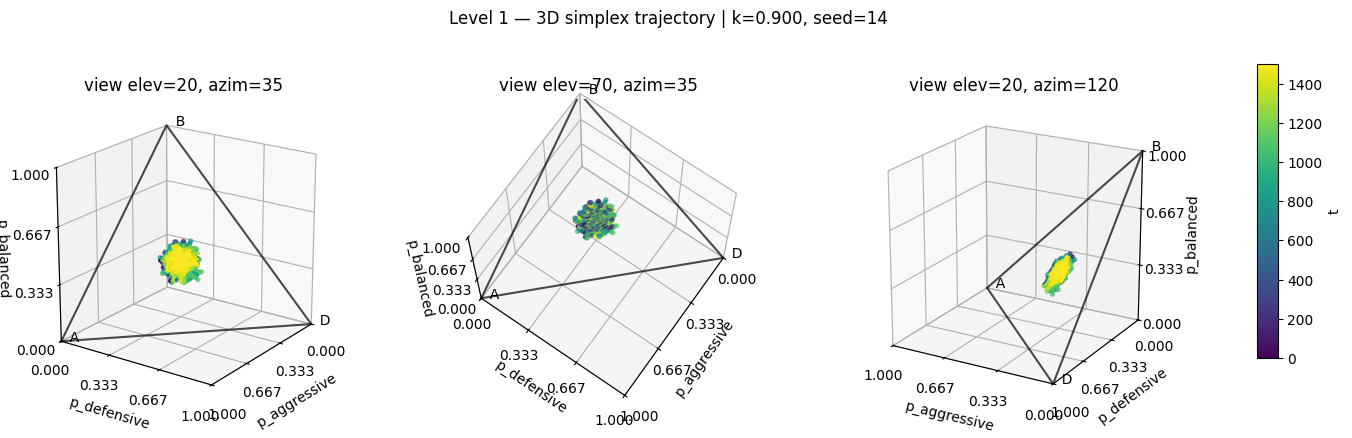

Level 2: not available
Level 3: not available


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

# 這個 cell 會用 reps[Level] 的設定來畫 3D simplex 軌跡（避免「找到 expected 代表，但畫圖用回 sampled」）。


def _simplex_frame(ax):
    # vertices in (A,D,B) coordinates
    V = np.array([
        [1.0, 0.0, 0.0],  # aggressive
        [0.0, 1.0, 0.0],  # defensive
        [0.0, 0.0, 1.0],  # balanced
    ])
    edges = [(0, 1), (1, 2), (2, 0)]
    for i, j in edges:
        ax.plot(*V[[i, j]].T, color="gray", linewidth=1, alpha=0.7)
    ax.scatter(V[:, 0], V[:, 1], V[:, 2], color="gray", s=20, alpha=0.9)
    ax.set_xlabel("p_aggressive")
    ax.set_ylabel("p_defensive")
    ax.set_zlabel("p_balanced")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=22, azim=-60)


def _trajectory_xyz(p_map: dict[str, list[float]]):
    x = np.asarray(p_map[STRATS[0]], dtype=float)
    y = np.asarray(p_map[STRATS[1]], dtype=float)
    z = np.asarray(p_map[STRATS[2]], dtype=float)
    # numerical safety: renormalize to simplex if needed
    s = x + y + z
    s[s == 0] = 1.0
    x, y, z = x / s, y / s, z / s
    return x, y, z


def _add_time_gradient_line(ax, x, y, z, *, cmap="viridis", lw=2.0, alpha=0.95):
    pts = np.column_stack([x, y, z]).reshape(-1, 1, 3)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    t = np.linspace(0, 1, len(segs))
    lc = Line3DCollection(segs, cmap=cmap, linewidth=lw, alpha=alpha)
    lc.set_array(t)
    ax.add_collection(lc)
    return lc


def _plot_level_3d(rep: SeedDiag, *, views=((22, -60), (40, 30), (10, 120))):
    # 用 rep 的 mode/N/k/seed 生成軌跡，避免和塞選來源不一致
    cfg = SimConfig(
        n_players=int(rep.n_players),
        n_rounds=int(ROUNDS_PLOT),
        seed=int(rep.seed),
        payoff_mode="matrix_ab",
        popularity_mode=str(rep.popularity_mode),
        evolution_mode=str(rep.evolution_mode),
        payoff_lag=1,
        gamma=0.1,
        epsilon=0.0,
        a=float(A),
        b=float(B),
        init_bias=float(INIT_BIAS),
        selection_strength=float(rep.k),
        out_csv=Path(""),
    )
    p_map = simulate_series_window(cfg, series="p", burn_in=0, tail=int(TAIL_PLOT), strategy_space=list(STRATS))
    res = _classify(p_map)
    x, y, z = _trajectory_xyz(p_map)

    fig = plt.figure(figsize=(12.0, 4.0))
    for i, (elev, azim) in enumerate(views, start=1):
        ax = fig.add_subplot(1, len(views), i, projection="3d")
        _simplex_frame(ax)
        lc = _add_time_gradient_line(ax, x, y, z)
        ax.view_init(elev=elev, azim=azim)
        ax.set_title(f"elev={elev}, azim={azim}")

    cbar = fig.colorbar(lc, ax=fig.axes, fraction=0.02, pad=0.02)
    cbar.set_label("time (normalized)")

    fig.suptitle(
        f"Level {rep.level} 3D simplex | mode={rep.popularity_mode}/{rep.evolution_mode} "
        f"N={rep.n_players}, k={rep.k:.3f}, seed={rep.seed} | stage3={rep.stage3_score:.3f}, dir={rep.stage3_dir:+d} | recomputed={res.level}"
    )
    plt.tight_layout()
    plt.show()


print("\n=== Full 3D (one per Level, if available) ===")
for lv in (1, 2, 3):
    if lv not in reps:
        print(f"Level {lv}: not available")
        continue
    _plot_level_3d(reps[lv])

## （保證輸出）完整 3D 三連發：Level1（sampled）/ Level2（stage3 強制 fail）/ Level3（mean_field）

如果目前 sampled 參數下很難自然找到 Level2/3（常見：都卡在 Level1 noisy cloud），
這段會用「同一條 mean_field 週期軌跡」，用不同 Stage3 門檻把它分成 Level2 與 Level3，
讓你直接看懂：Level2 vs Level3 的差別到底是什麼。

Case L1 sampled: {'seed': 32, 'k': 1.4, 'level': 1}


/tmp/ipykernel_505856/3180532778.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.93])


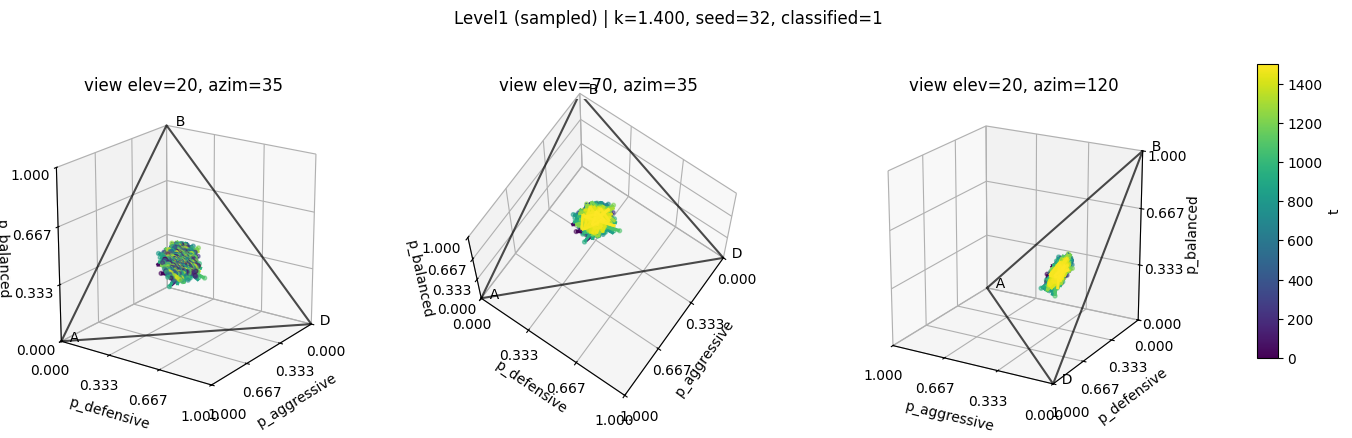

Case L2 (same mf, stage3 forced fail): {'k': 0.9, 'seed': 0, 'level': 2}
Case L3 mean_field: {'k': 0.9, 'seed': 0, 'level': 3}


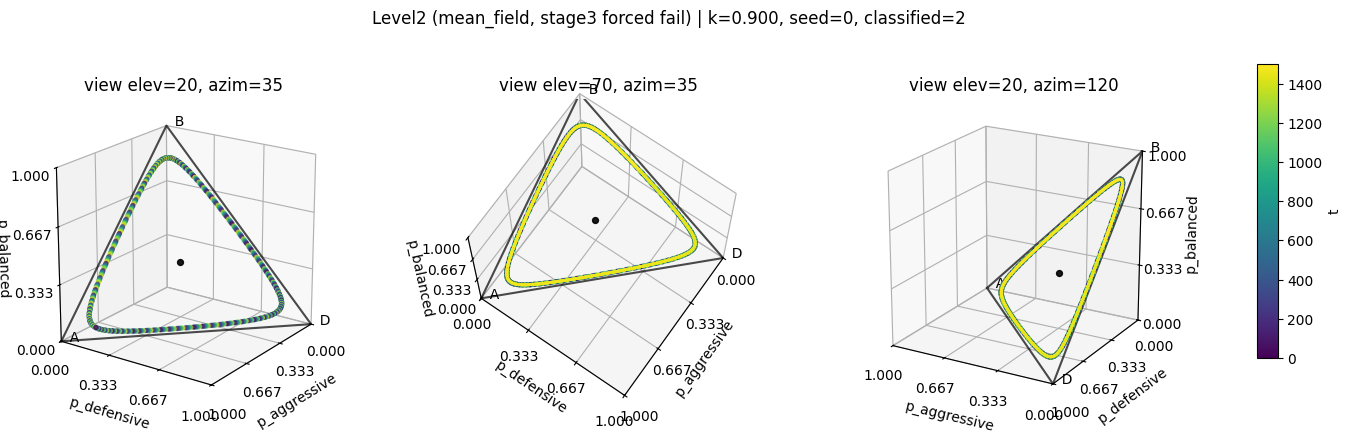

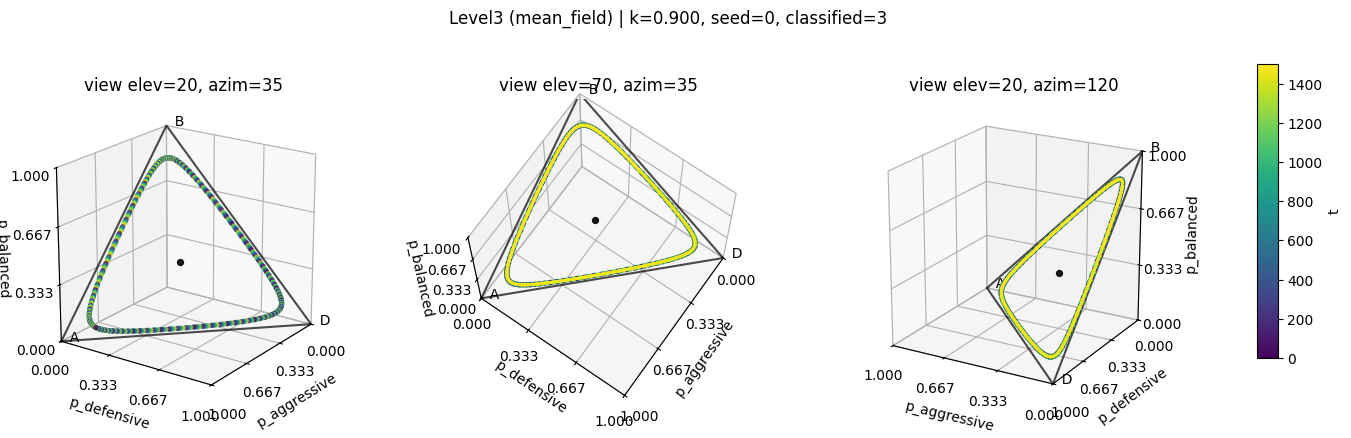

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection

# 確保 import 路徑
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "simulation").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from simulation.run_simulation import SimConfig, simulate_series_window
from analysis.cycle_metrics import classify_cycle_level

STRATS = ("aggressive", "defensive", "balanced")

# ---- shared params ----
A = 0.4
B = 0.2425406997
N = 200
TAIL = 1500
T = 3000
INIT_BIAS = 0.01

# sampled Level1：優先用上一格找到的 reps[1]，否則 fallback
seed_L1 = 0
k_L1 = 1.04
if "reps" in globals() and isinstance(reps, dict) and 1 in reps:
    seed_L1 = int(reps[1].seed)
    k_L1 = float(reps[1].k)

# mean_field：用固定參數保證有乾淨旋轉
seed_mf = 0
k_mf = 0.9

base_common = dict(
    n_players=N,
    n_rounds=T,
    payoff_mode="matrix_ab",
    gamma=0.1,
    epsilon=0.0,
    a=A,
    b=B,
    init_bias=INIT_BIAS,
    payoff_lag=1,
    out_csv=Path(""),
 )


def _simplex_vertices_3d() -> dict[str, np.ndarray]:
    return {
        "A": np.array([1.0, 0.0, 0.0]),
        "D": np.array([0.0, 1.0, 0.0]),
        "B": np.array([0.0, 0.0, 1.0]),
    }


def _plot_simplex_frame(ax) -> None:
    V = _simplex_vertices_3d()
    A_, D_, B_ = V["A"], V["D"], V["B"]
    tri = np.stack([A_, D_, B_, A_], axis=0)
    ax.plot(tri[:, 0], tri[:, 1], tri[:, 2], color="black", linewidth=1.5, alpha=0.7)
    c = np.array([1.0 / 3.0, 1.0 / 3.0, 1.0 / 3.0])
    ax.scatter([c[0]], [c[1]], [c[2]], color="black", s=18, alpha=0.9)
    ax.text(A_[0], A_[1], A_[2], "  A", color="black")
    ax.text(D_[0], D_[1], D_[2], "  D", color="black")
    ax.text(B_[0], B_[1], B_[2], "  B", color="black")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)
    ax.set_xlabel("p_aggressive")
    ax.set_ylabel("p_defensive")
    ax.set_zlabel("p_balanced")
    ax.set_box_aspect((1, 1, 1))
    ax.set_xticks([0, 1 / 3, 2 / 3, 1.0])
    ax.set_yticks([0, 1 / 3, 2 / 3, 1.0])
    ax.set_zticks([0, 1 / 3, 2 / 3, 1.0])


def _line3d_time_gradient(ax, x: np.ndarray, y: np.ndarray, z: np.ndarray, *, cmap="viridis") -> Line3DCollection | None:
    pts = np.column_stack([x, y, z])
    if len(pts) < 2:
        return None
    segs = np.stack([pts[:-1], pts[1:]], axis=1)
    norm = Normalize(vmin=0, vmax=len(pts) - 1)
    lc = Line3DCollection(segs, cmap=cmap, norm=norm)
    lc.set_array(np.arange(len(pts) - 1))
    lc.set_linewidth(2.0)
    ax.add_collection3d(lc)
    step = max(1, len(pts) // 700)
    ax.scatter(x[::step], y[::step], z[::step], c=np.arange(len(pts))[::step], cmap=cmap, s=8, alpha=0.55)
    return lc


def _get_p_series(cfg: SimConfig) -> dict[str, list[float]]:
    return simulate_series_window(cfg, series="p", burn_in=0, tail=TAIL, strategy_space=list(STRATS))


def _classify_level(p_map: dict[str, list[float]], *, min_turn_strength: float) -> int:
    res = classify_cycle_level(
        p_map,
        burn_in=0,
        tail=None,
        strategies=STRATS,
        stage3_method="turning",
        stage3_window=240,
        stage3_step=20,
        stage3_quantile=0.75,
        eta=0.6,
        min_turn_strength=float(min_turn_strength),
    )
    return int(res.level)


def _plot_case(*, title: str, p_map: dict[str, list[float]]):
    x = np.asarray(p_map[STRATS[0]], dtype=float)
    y = np.asarray(p_map[STRATS[1]], dtype=float)
    z = np.asarray(p_map[STRATS[2]], dtype=float)

    angles = [(20, 35), (70, 35), (20, 120)]
    fig = plt.figure(figsize=(14, 4.2))
    fig.suptitle(title)
    last_lc = None
    for i, (elev, azim) in enumerate(angles, start=1):
        ax = fig.add_subplot(1, len(angles), i, projection="3d")
        _plot_simplex_frame(ax)
        last_lc = _line3d_time_gradient(ax, x, y, z, cmap="viridis")
        ax.view_init(elev=float(elev), azim=float(azim))
        ax.set_title(f"view elev={elev}, azim={azim}")
    if last_lc is not None:
        cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
        cb = fig.colorbar(last_lc, cax=cax)
        cb.set_label("t")
    plt.tight_layout(rect=[0, 0, 0.9, 0.93])
    plt.show()


# ---- Case 1: Level1 sampled ----
cfg_L1 = SimConfig(
    **base_common,
    seed=int(seed_L1),
    selection_strength=float(k_L1),
    popularity_mode="sampled",
    evolution_mode="sampled",
 )
p_L1 = _get_p_series(cfg_L1)
lvl_L1 = _classify_level(p_L1, min_turn_strength=0.0)
print("Case L1 sampled:", {"seed": seed_L1, "k": k_L1, "level": lvl_L1})
_plot_case(title=f"Level1 (sampled) | k={k_L1:.3f}, seed={seed_L1}, classified={lvl_L1}", p_map=p_L1)

# ---- Case 2/3: same mean_field trajectory, but change Stage3 threshold ----
cfg_mf = SimConfig(
    **base_common,
    seed=int(seed_mf),
    selection_strength=float(k_mf),
    popularity_mode="sampled",
    evolution_mode="mean_field",
 )
p_mf = _get_p_series(cfg_mf)

lvl_L2 = _classify_level(p_mf, min_turn_strength=2.0)  # 強制讓 stage3 fail -> Level2
lvl_L3 = _classify_level(p_mf, min_turn_strength=0.0)  # 正常 stage3 -> Level3
print("Case L2 (same mf, stage3 forced fail):", {"k": k_mf, "seed": seed_mf, "level": lvl_L2})
print("Case L3 mean_field:", {"k": k_mf, "seed": seed_mf, "level": lvl_L3})

_plot_case(title=f"Level2 (mean_field, stage3 forced fail) | k={k_mf:.3f}, seed={seed_mf}, classified={lvl_L2}", p_map=p_mf)
_plot_case(title=f"Level3 (mean_field) | k={k_mf:.3f}, seed={seed_mf}, classified={lvl_L3}", p_map=p_mf)

## 直接用 sweep CSV 構圖（Level 1/2/3）
這段不重跑模擬：直接讀 `simulation/rho_curve.py` 產出的彙總 CSV（例如 `outputs/_rho_curve_*.csv`）。
CSV 通常只有 `p_level_ge_2` 與 `p_level_3`，因此：
- $P(L1)=1-P(L\ge 2)$
- $P(L2)=P(L\ge 2)-P(L3)$
- $P(L3)=P(L3)$


CSV: /home/user/personality-dungeon/outputs/_rho_curve_smoke.csv
players available: [50, 200]
players plotted: [50, 200]


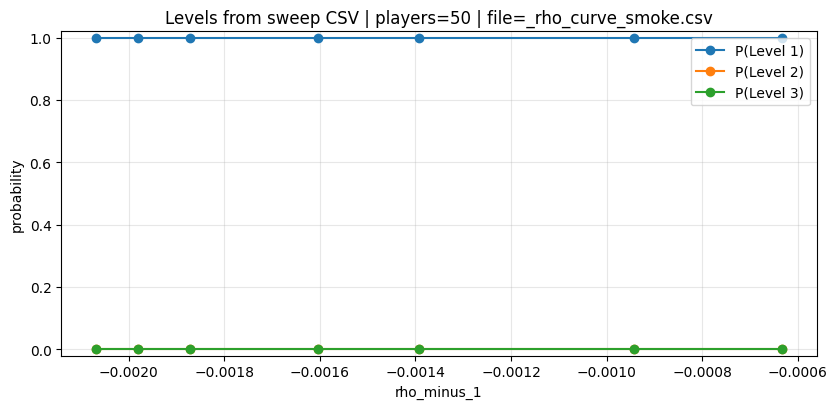

rows used (players=50): 7


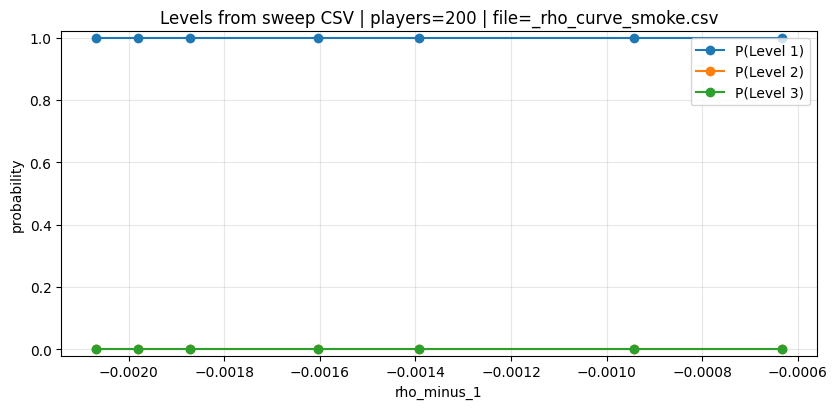

rows used (players=200): 7


In [11]:
from __future__ import annotations

from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

# 1) 選一個你要畫的 sweep CSV（rho_curve 類）
CSV_PATH = project_root / "outputs" / "_rho_curve_smoke.csv"  # 可換成 _rho_curve_eta055_short.csv 等

# 2) 選 x 軸：'rho_minus_1'（建議）或 'selection_strength'
X_AXIS = "rho_minus_1"

# 3) 繪圖模式：
# - 'separate'：每個 players 各一張圖（每張含 L1/L2/L3）
# - 'overlay'：同一張圖疊 players 曲線（用 3 個子圖分別顯示 L1/L2/L3）
MODE = "separate"  # 'separate' | 'overlay'

# 4) 想畫哪些 players：None 代表用 CSV 裡全部 players；或指定例如 [50, 200]
PLAYERS_LIST = None  # e.g. [50, 200]


def _read_csv_rows(path: Path) -> list[dict]:
    if not path.exists():
        raise FileNotFoundError(f"CSV not found: {path}")
    with path.open(newline="") as rf:
        reader = csv.DictReader(rf)
        return [dict(r) for r in reader]


def _extract_players(rows: list[dict]) -> list[int]:
    return sorted({int(float(r["players"])) for r in rows})


def _subset_by_players(rows: list[dict], players: int) -> list[dict]:
    sub = [r for r in rows if int(float(r["players"])) == int(players)]
    return sorted(sub, key=lambda r: float(r[X_AXIS]))


def _levels_from_rows(sub_sorted: list[dict]):
    x = np.asarray([float(r[X_AXIS]) for r in sub_sorted], dtype=float)
    p_ge2 = np.asarray([float(r["p_level_ge_2"]) for r in sub_sorted], dtype=float)
    p3 = np.asarray([float(r["p_level_3"]) for r in sub_sorted], dtype=float)
    p1 = 1.0 - p_ge2
    p2 = p_ge2 - p3
    return x, p1, p2, p3


rows = _read_csv_rows(Path(CSV_PATH))
if not rows:
    raise ValueError(f"CSV is empty: {CSV_PATH}")

# 欄位檢查
need = {"players", "p_level_ge_2", "p_level_3", X_AXIS}
missing = [k for k in sorted(need) if k not in rows[0]]
if missing:
    raise KeyError(f"CSV missing columns: {missing}. Available: {list(rows[0].keys())}")

players_available = _extract_players(rows)
if PLAYERS_LIST is None:
    players_to_plot = players_available
else:
    players_to_plot = [int(p) for p in PLAYERS_LIST]
    bad = [p for p in players_to_plot if p not in players_available]
    if bad:
        raise ValueError(f"PLAYERS_LIST contains missing players={bad}. Available: {players_available}")

print("CSV:", CSV_PATH)
print("players available:", players_available)
print("players plotted:", players_to_plot)

mode = str(MODE).strip().lower()
if mode not in ("separate", "overlay"):
    raise ValueError("MODE must be 'separate' or 'overlay'")

if mode == "separate":
    for p in players_to_plot:
        sub_sorted = _subset_by_players(rows, players=int(p))
        if not sub_sorted:
            continue
        x, p1, p2, p3 = _levels_from_rows(sub_sorted)

        fig, ax = plt.subplots(figsize=(8.5, 4.2))
        ax.plot(x, p1, marker="o", linewidth=1.5, label="P(Level 1)")
        ax.plot(x, p2, marker="o", linewidth=1.5, label="P(Level 2)")
        ax.plot(x, p3, marker="o", linewidth=1.5, label="P(Level 3)")
        ax.set_ylim(-0.02, 1.02)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel(X_AXIS)
        ax.set_ylabel("probability")
        ax.set_title(f"Levels from sweep CSV | players={p} | file={Path(CSV_PATH).name}")
        ax.legend()
        plt.tight_layout()
        plt.show()
        print("rows used (players=%s):" % p, len(sub_sorted))

else:  # overlay
    # 同圖比較不同 players：用 3 個子圖（L1/L2/L3）讓線數不爆掉
    fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.8), sharex=True, sharey=True)
    level_names = {1: "P(Level 1)", 2: "P(Level 2)", 3: "P(Level 3)"}
    for ax, lv in zip(axes, (1, 2, 3)):
        for p in players_to_plot:
            sub_sorted = _subset_by_players(rows, players=int(p))
            if not sub_sorted:
                continue
            x, p1, p2, p3 = _levels_from_rows(sub_sorted)
            y = {1: p1, 2: p2, 3: p3}[lv]
            ax.plot(x, y, marker="o", linewidth=1.5, label=f"players={p}")
        ax.set_title(level_names[lv])
        ax.grid(True, alpha=0.3)
        ax.set_xlabel(X_AXIS)
    axes[0].set_ylabel("probability")
    axes[0].set_ylim(-0.02, 1.02)
    axes[-1].legend(loc="best")
    fig.suptitle(f"Overlay by players | file={Path(CSV_PATH).name}")
    plt.tight_layout()
    plt.show()